[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337 -0.23413696
  1.57921282  0.76743473 -0.46947439  0.54256004 -0.46341769 -0.46572975
  0.24196227 -1.91328024 -1.72491783 -0.56228753 -1.01283112  0.31424733
 -0.90802408 -1.4123037   1.46564877 -0.2257763   0.0675282  -1.42474819
 -0.54438272  0.11092259 -1.15099358  0.37569802 -0.60063869 -0.29169375
 -0.60170661  1.85227818 -0.01349722 -1.05771093  0.82254491 -1.22084365
  0.2088636  -1.95967012 -1.32818605  0.19686124  0.73846658  0.17136828
 -0.11564828 -0.3011037  -1.47852199 -0.71984421 -0.46063877  1.05712223
  0.34361829 -1.76304016  0.32408397 -0.38508228 -0.676922    0.61167629
  1.03099952  0.93128012 -0.83921752 -0.30921238  0.33126343  0.97554513
 -0.47917424 -0.18565898 -1.10633497 -1.19620662  0.81252582  1.35624003
 -0.07201012  1.0035329   0.36163603 -0.64511975  0.36139561  1.53803657
 -0.03582604  1.56464366 -2.6197451   0.8219025   0.08704707 -0.29900735
  0.09176078 -1.98756891 -0.21967189  0.35711257  1

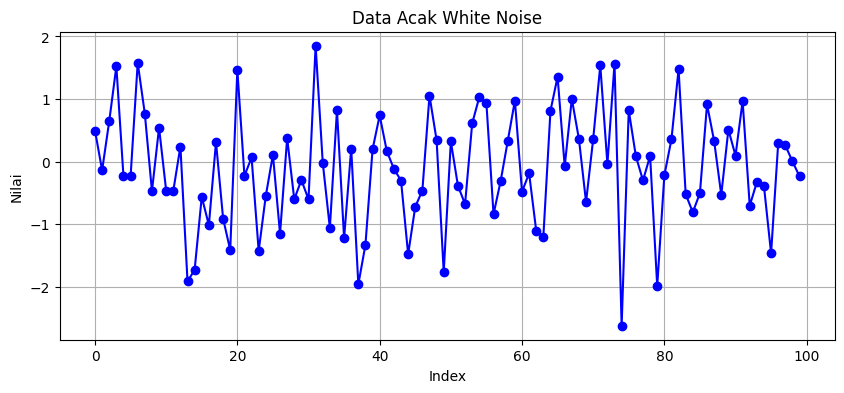

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulasi white noise dengan 100 data acak
np.random.seed(42)  # biar hasilnya bisa direplikasi
white_noise = np.random.normal(0, 1, 100)

# Tampilkan data
print(white_noise)

# Visualisasi
plt.figure(figsize=(10,4))
plt.plot(white_noise, marker='o', linestyle='-', color='blue')
plt.title("Data Acak White Noise")
plt.xlabel("Index")
plt.ylabel("Nilai")
plt.grid(True)
plt.show()

<Figure size 800x400 with 0 Axes>

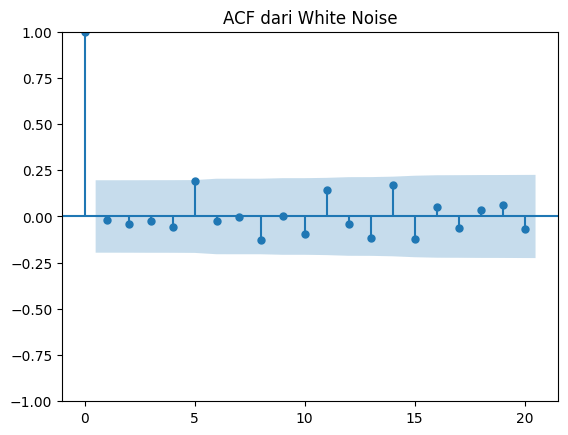

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf


# 3. Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8,4))
plot_acf(white_noise, lags=20)
plt.title("ACF dari White Noise")
plt.show()

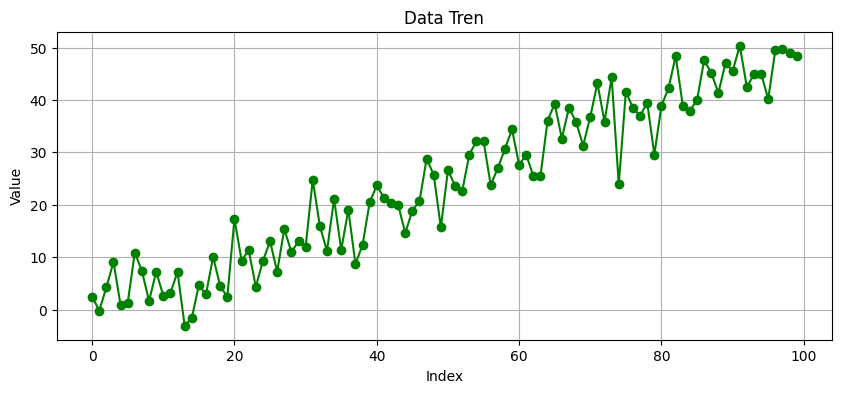

<Figure size 800x400 with 0 Axes>

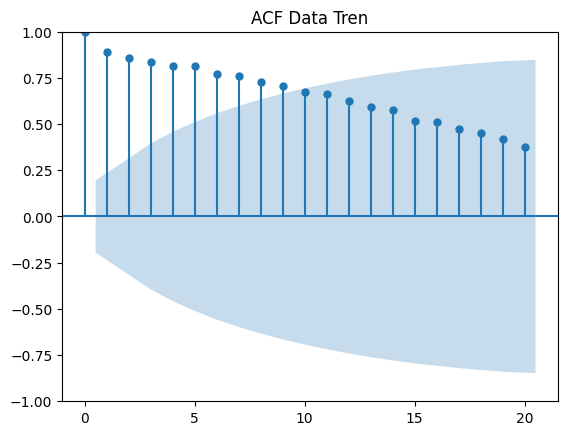

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# 1. Buat data random dengan tren
np.random.seed(42)

n = 100
time = np.arange(n)

# Komponen tren linear
trend = 0.5 * time

# Komponen noise (acak normal)
noise = np.random.normal(0, 5, n)

# Gabungan data = tren + noise
data_with_trend = trend + noise

# 2. Plot data time series dengan tren
plt.figure(figsize=(10,4))
plt.plot(time, data_with_trend, marker='o', linestyle='-', color='green')
plt.title("Data Tren")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.show()

# 3. Plot ACF
plt.figure(figsize=(8,4))
plot_acf(data_with_trend, lags=20)
plt.title("ACF Data Tren")
plt.show()


# Autoregressive Process


Fungsi Simulasi AR(1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess
import warnings
warnings.filterwarnings("ignore")

# Fungsi simulasi AR(1)
def simulate_ar1(phi, n, burn=200, sigma=1.0, random_state=None):
    rng = np.random.default_rng(random_state)
    ar = np.array([1, -phi])  # AR(1) parameter
    ma = np.array([1])
    arma = ArmaProcess(ar, ma)
    x = arma.generate_sample(nsample=n+burn, scale=sigma, distrvs=rng.standard_normal)
    return x[burn:]

Fungsi Looping semua parameter


=== Simulasi untuk phi = 0.01, n = 100, seed = 42 ===


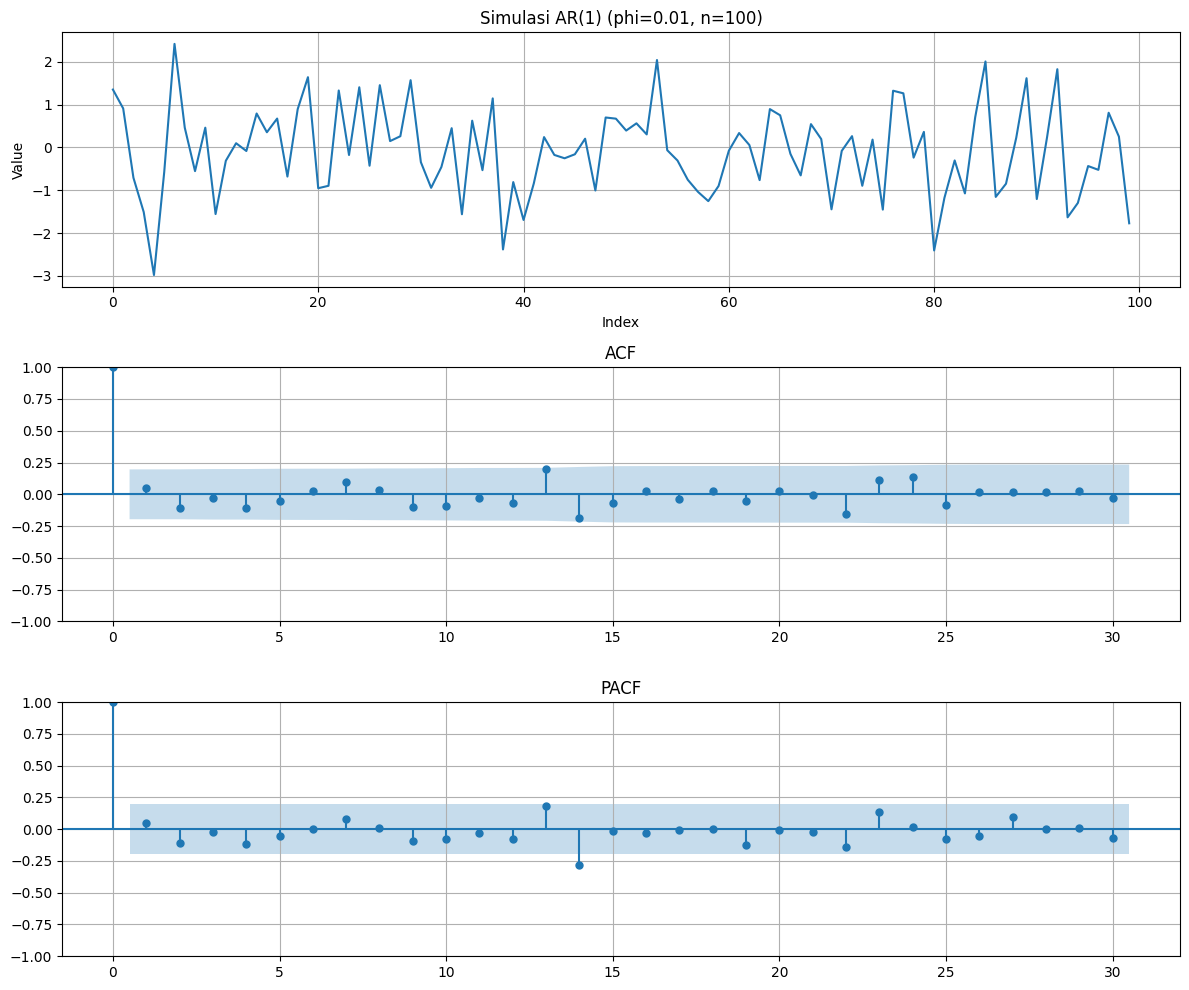


=== Simulasi untuk phi = 0.01, n = 200, seed = 42 ===


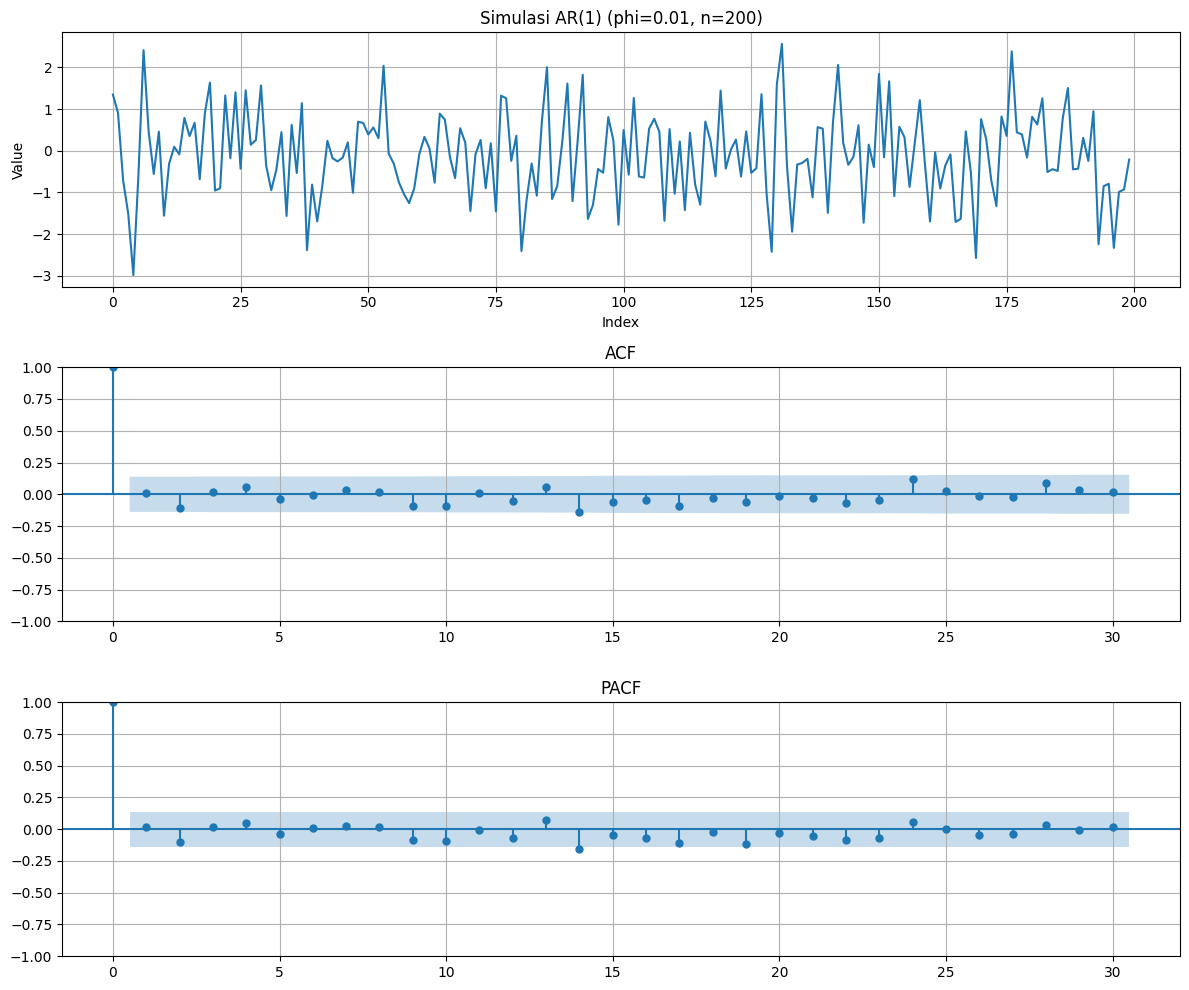


=== Simulasi untuk phi = 0.01, n = 500, seed = 42 ===


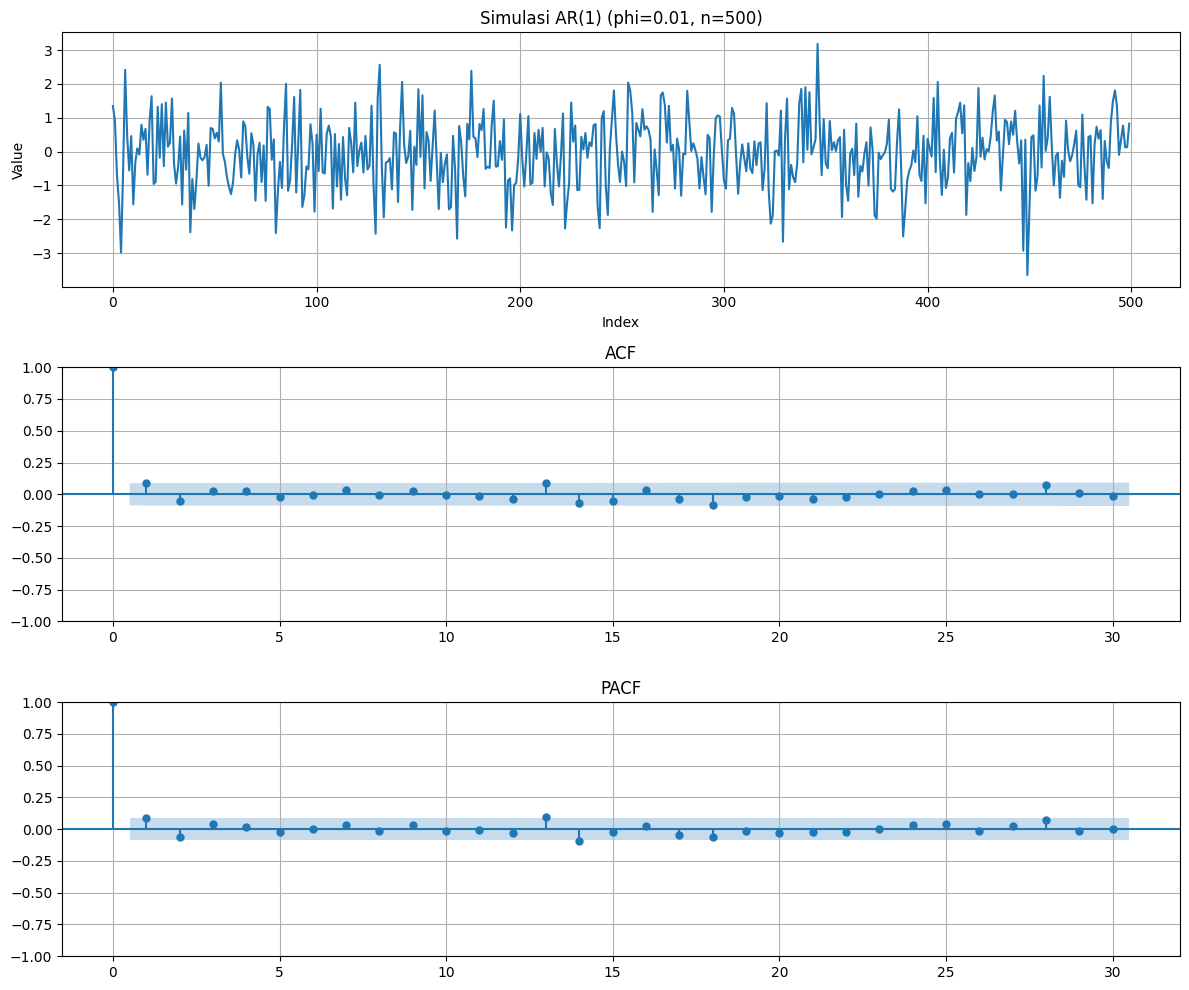


=== Simulasi untuk phi = 0.01, n = 1000, seed = 42 ===


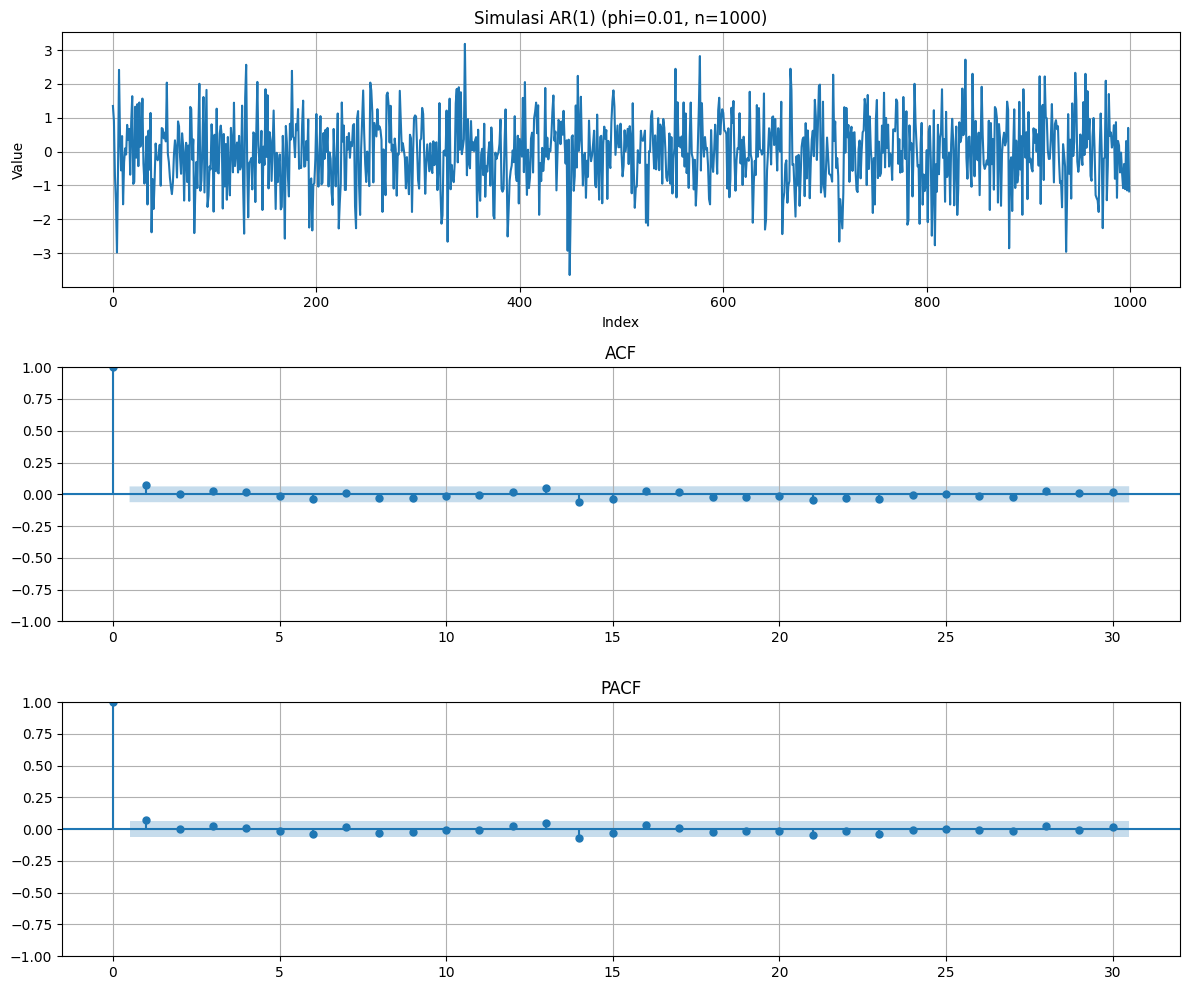


=== Simulasi untuk phi = 0.7, n = 100, seed = 42 ===


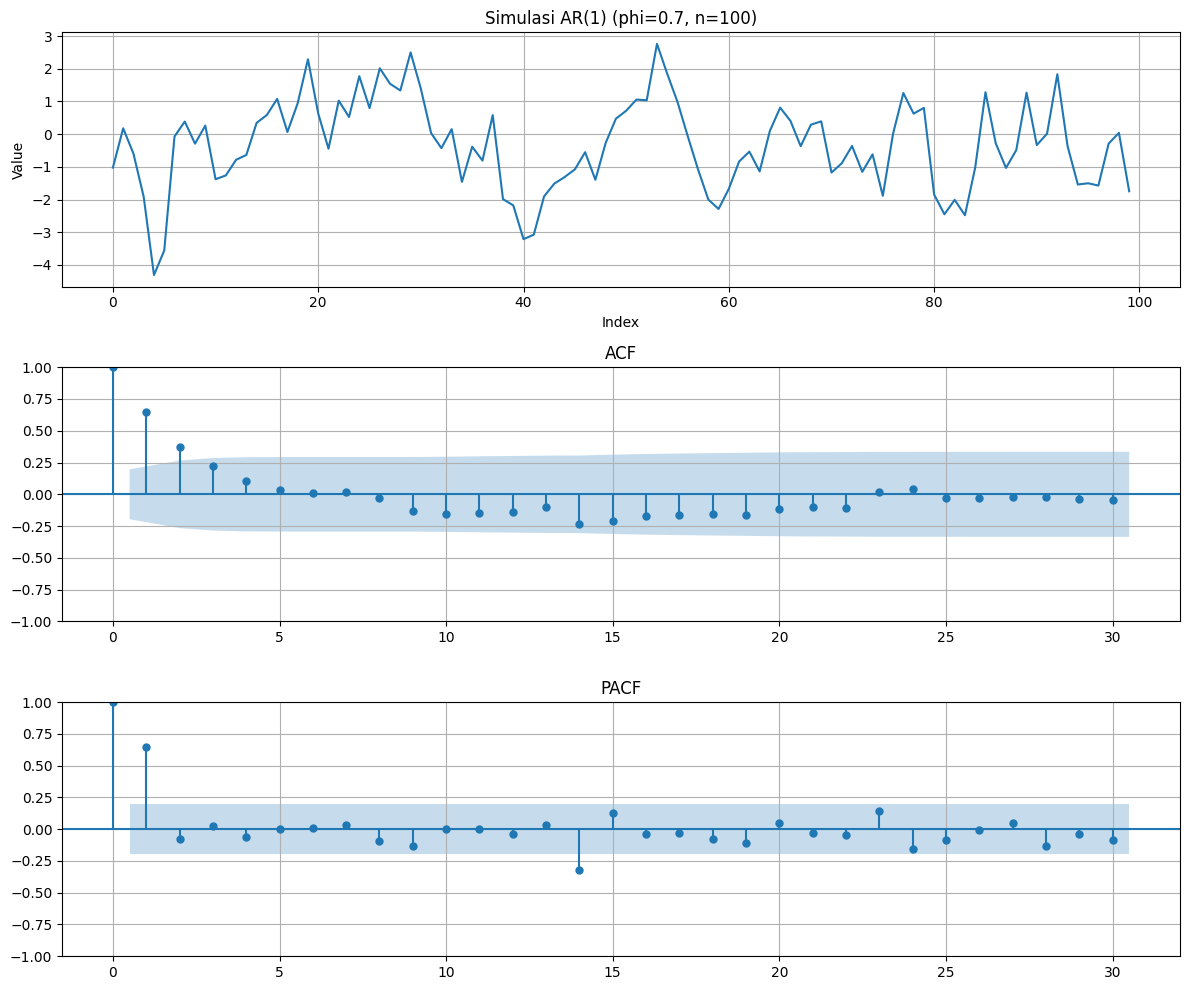


=== Simulasi untuk phi = 0.7, n = 200, seed = 42 ===


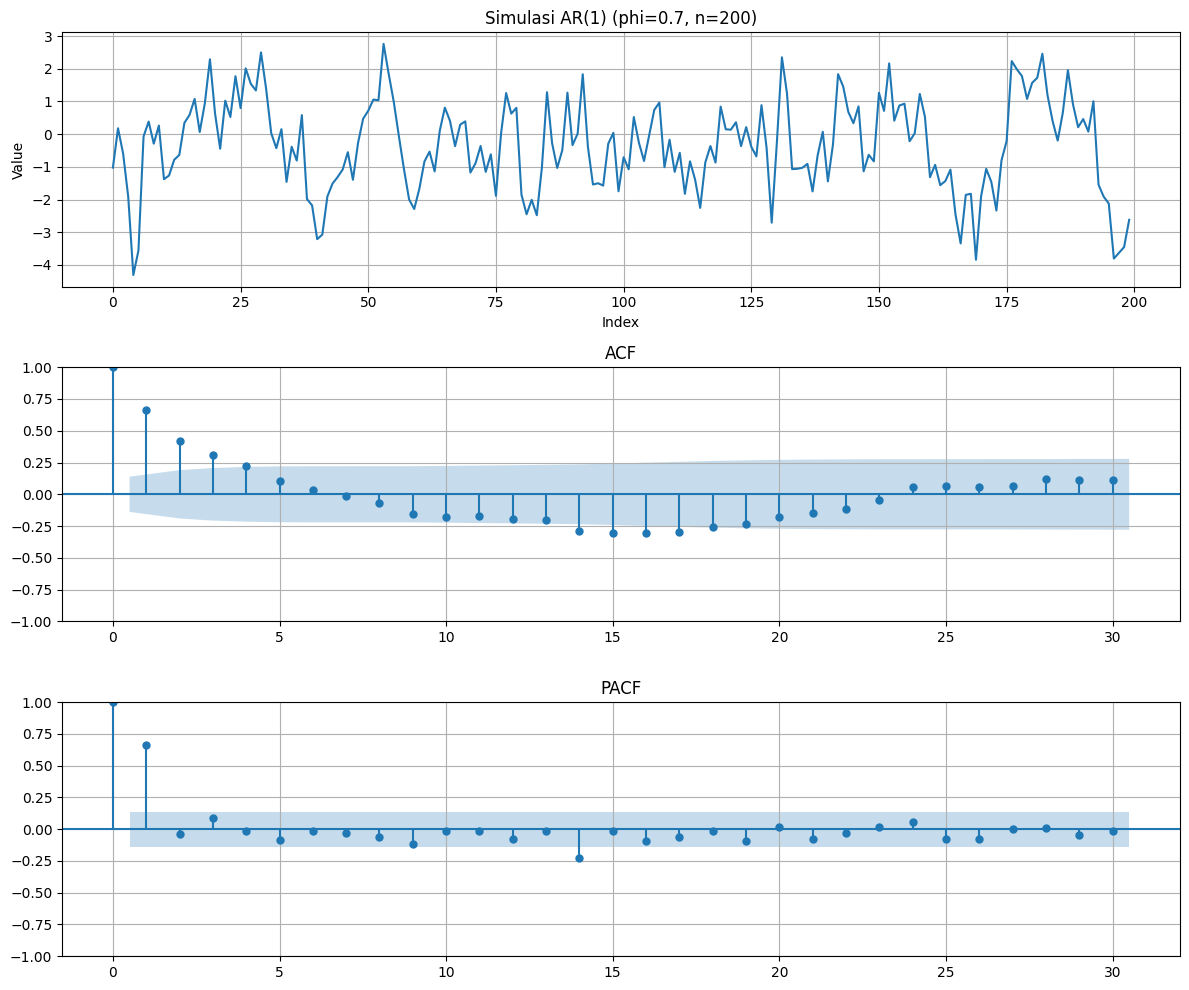


=== Simulasi untuk phi = 0.7, n = 500, seed = 42 ===


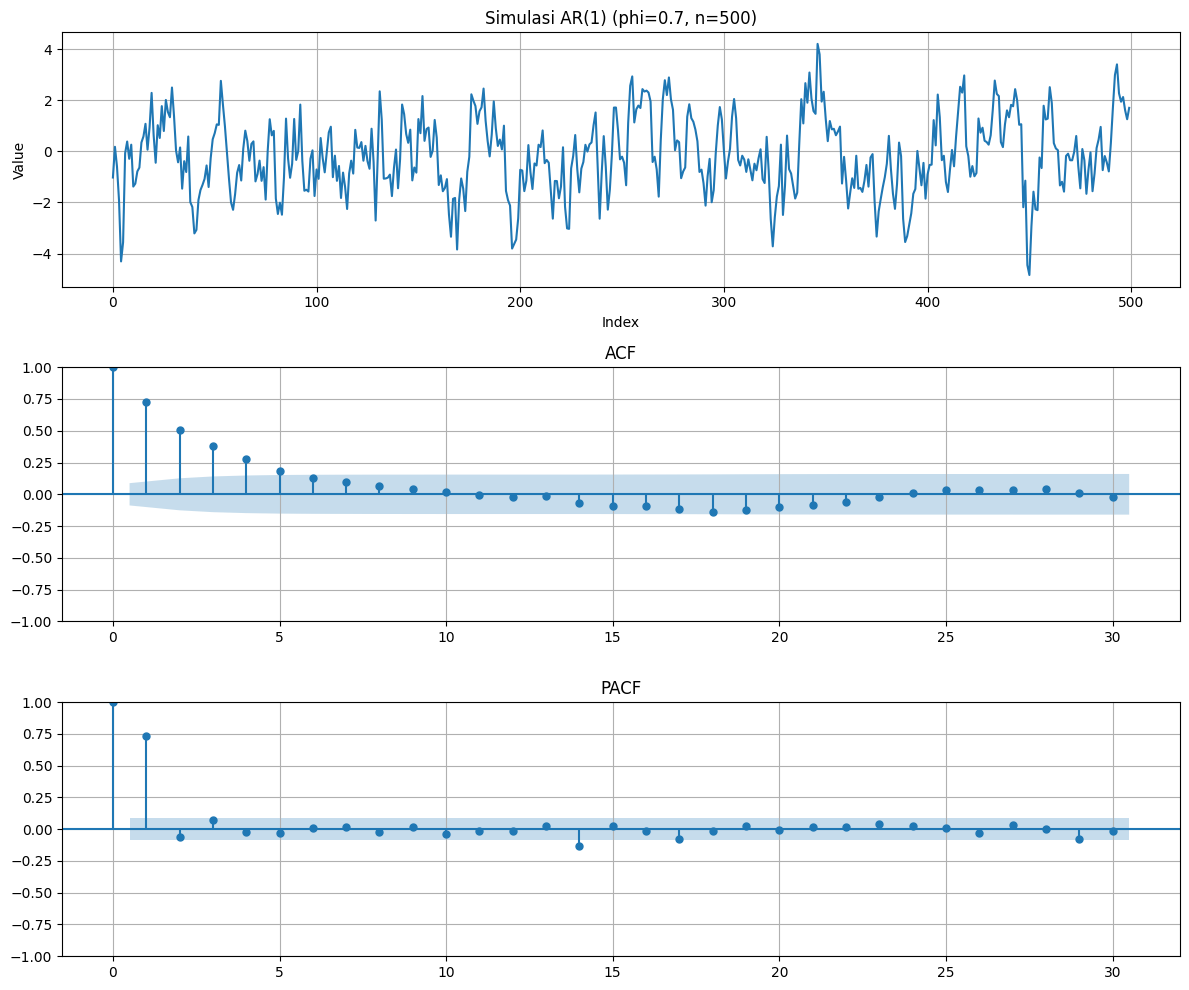


=== Simulasi untuk phi = 0.7, n = 1000, seed = 42 ===


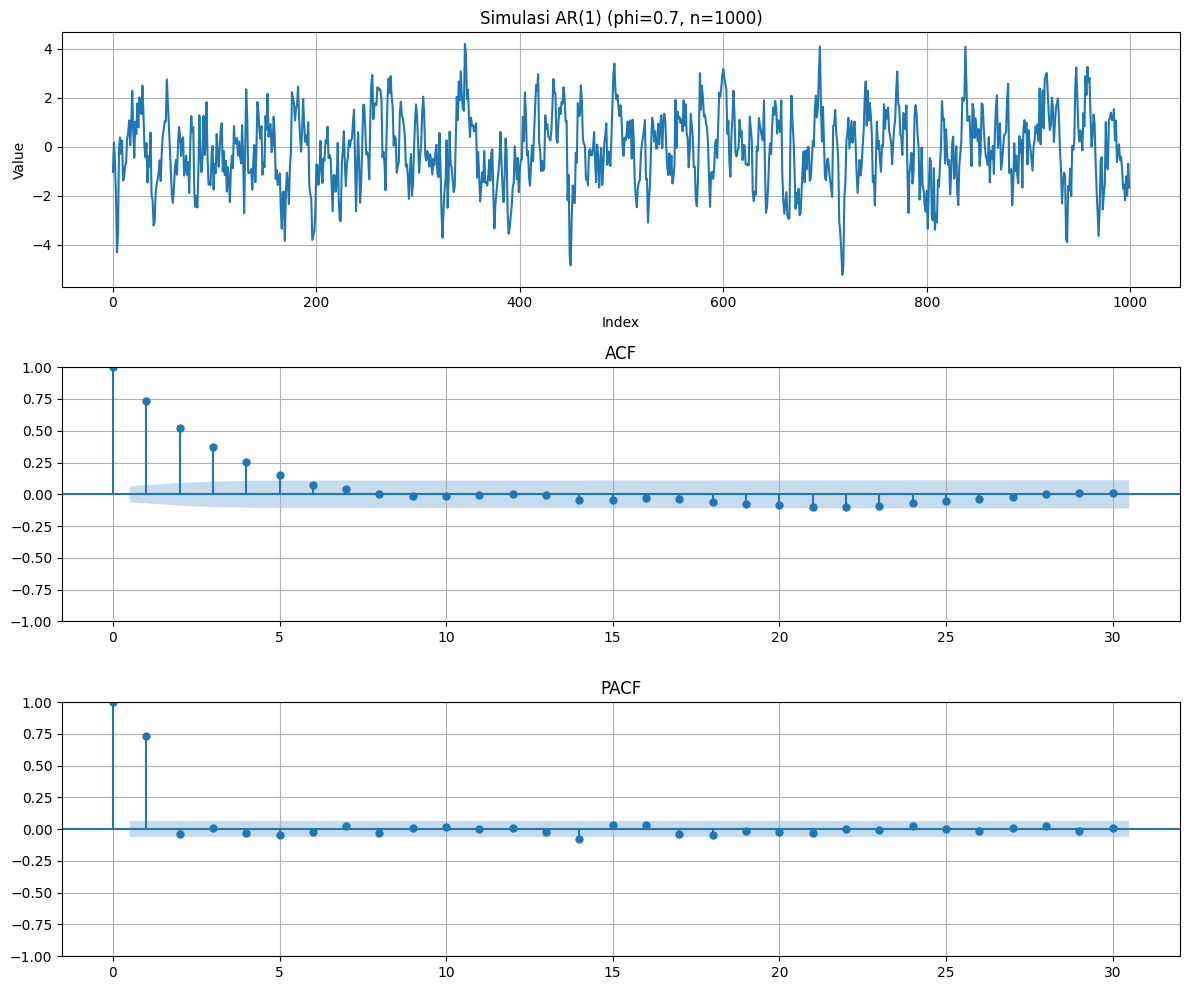


=== Simulasi untuk phi = 0.99, n = 100, seed = 42 ===


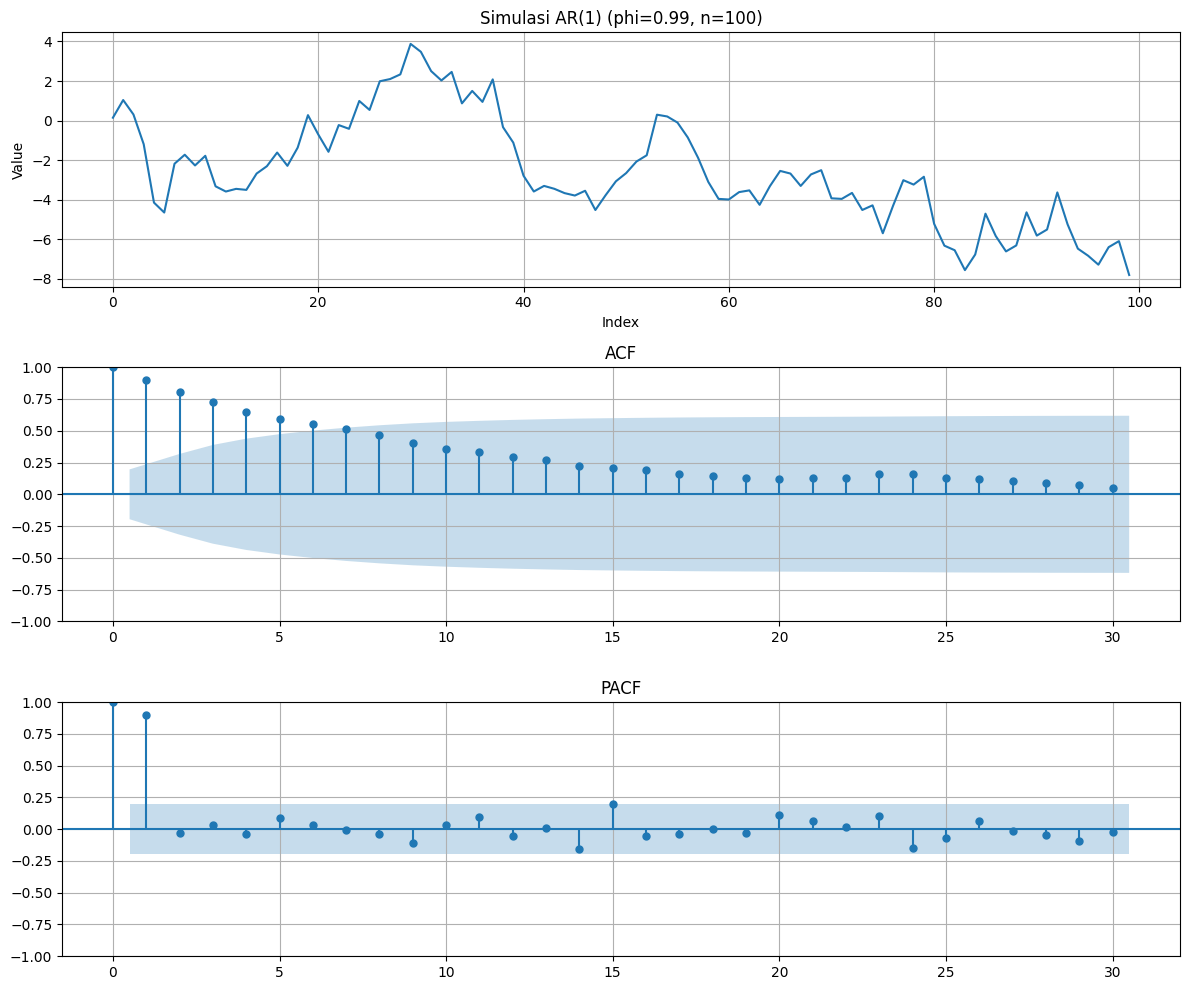


=== Simulasi untuk phi = 0.99, n = 200, seed = 42 ===


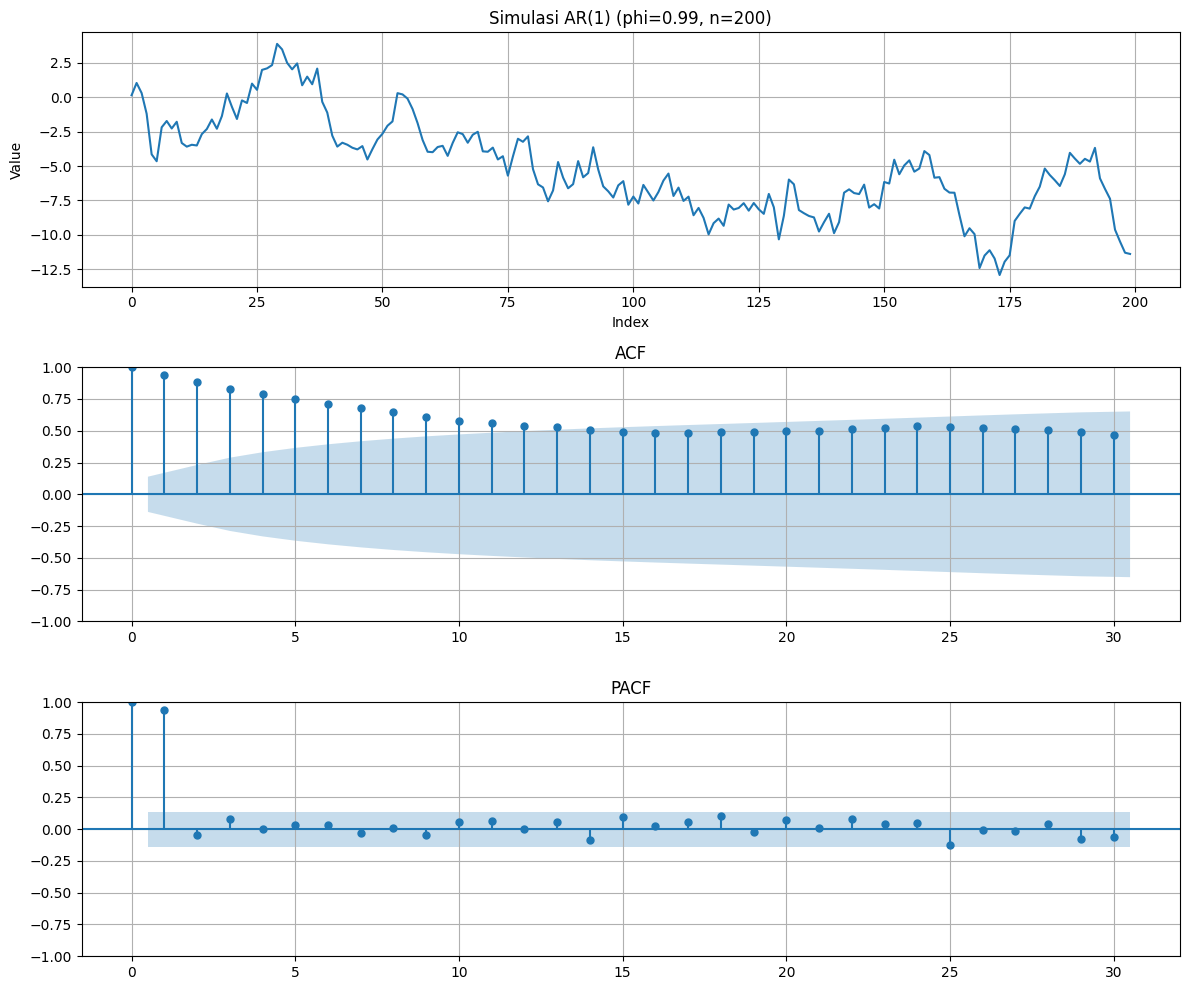


=== Simulasi untuk phi = 0.99, n = 500, seed = 42 ===


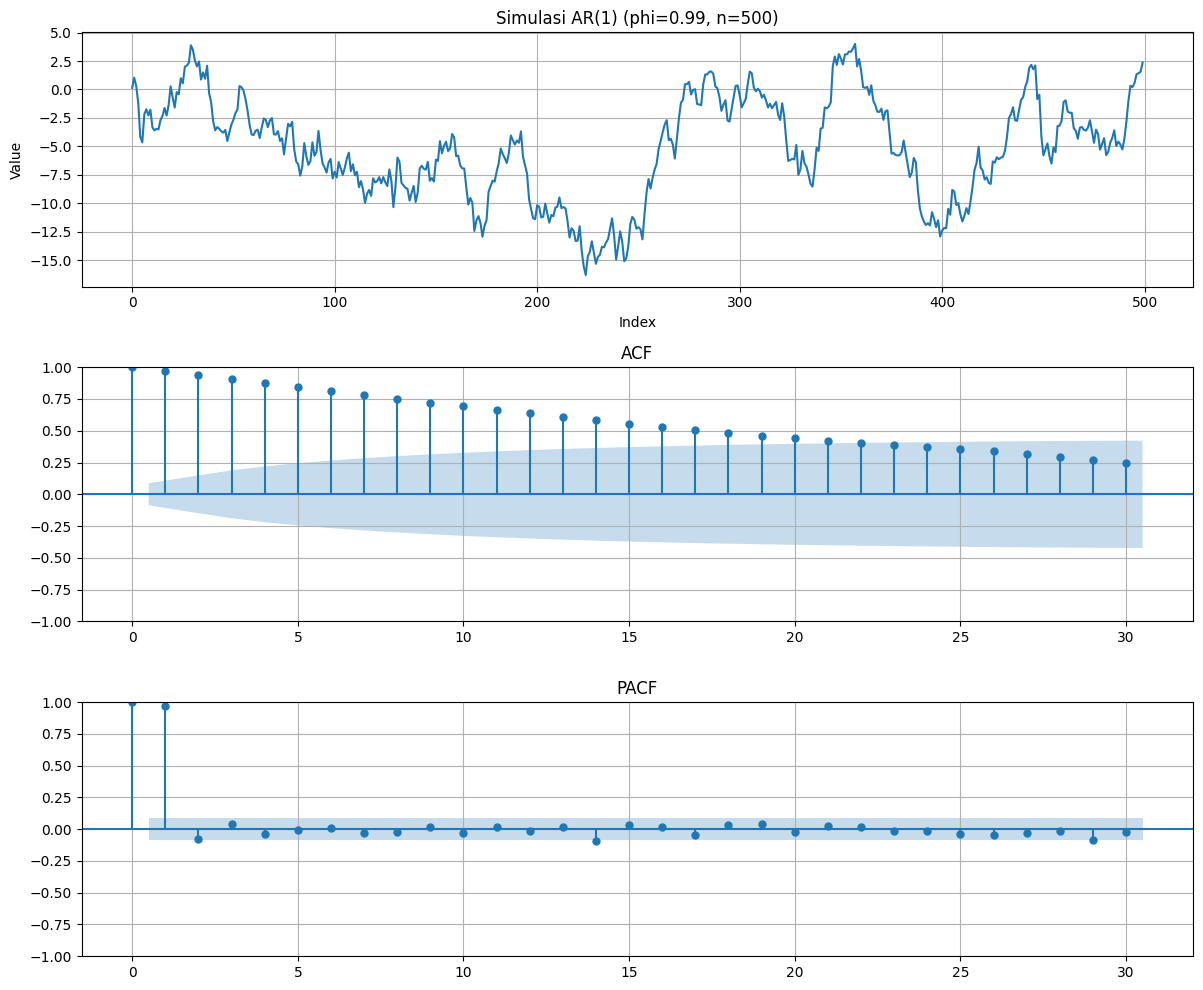


=== Simulasi untuk phi = 0.99, n = 1000, seed = 42 ===


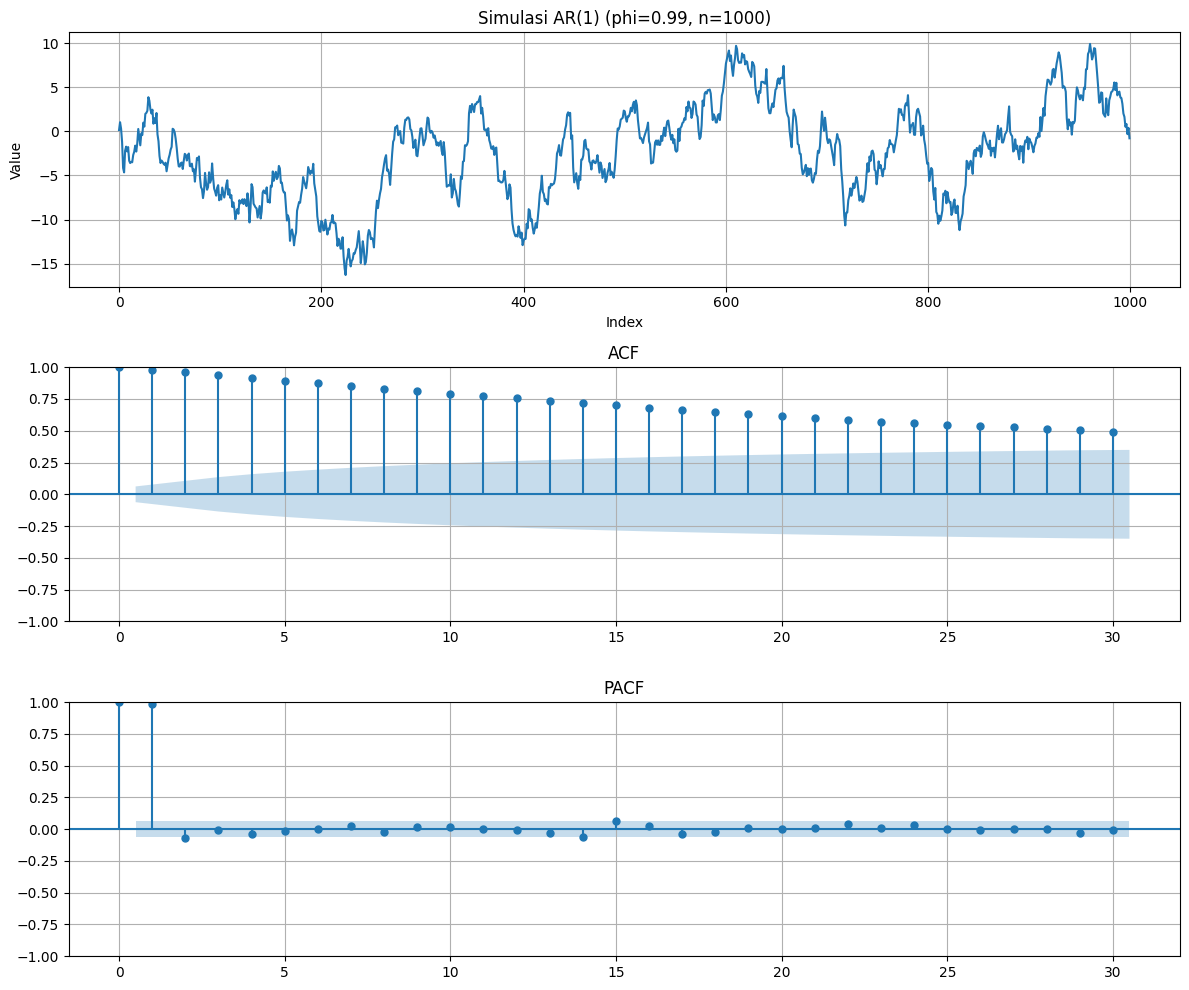

In [ ]:
phi_values = [0.01, 0.7, 0.99]
n_values = [100, 200, 500, 1000]

# Tetapkan random seed global
seed = 42

for phi in phi_values:
    for n in n_values:
        print(f"\n=== Simulasi untuk phi = {phi}, n = {n}, seed = {seed} ===")
        x = simulate_ar1(phi, n, burn=500, random_state=seed)
        plot_series_and_acf_pacf(x, phi, n, lags=30)

In [ ]:
# Fungsi untuk memplot time series, ACF, dan PACF
def plot_series_and_acf_pacf(x, phi, n, lags=30):
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))

    # Plot Time Series
    axes[0].plot(x)
    axes[0].set_title(f"Simulasi AR(1) (phi={phi}, n={n})")
    axes[0].set_xlabel("Index")
    axes[0].set_ylabel("Value")
    axes[0].grid(True)

    # Plot ACF
    plot_acf(x, lags=lags, ax=axes[1])
    axes[1].set_title("ACF")
    axes[1].grid(True)

    # Plot PACF
    plot_pacf(x, lags=lags, ax=axes[2])
    axes[2].set_title("PACF")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

# Moving Average

Looping Simulasi MA(1)

<Figure size 800x400 with 0 Axes>

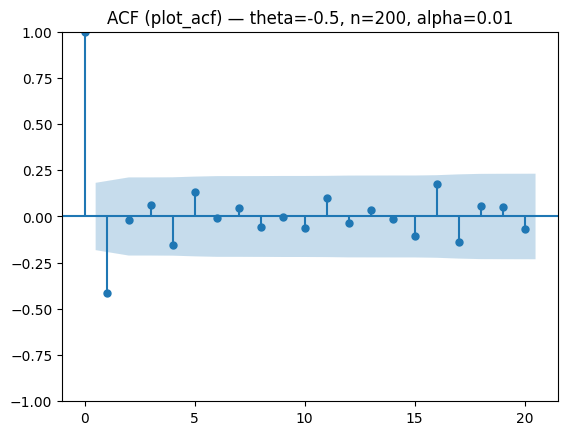

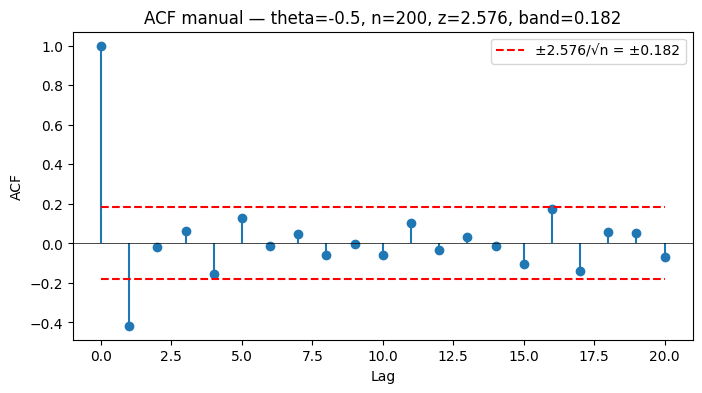

<Figure size 800x400 with 0 Axes>

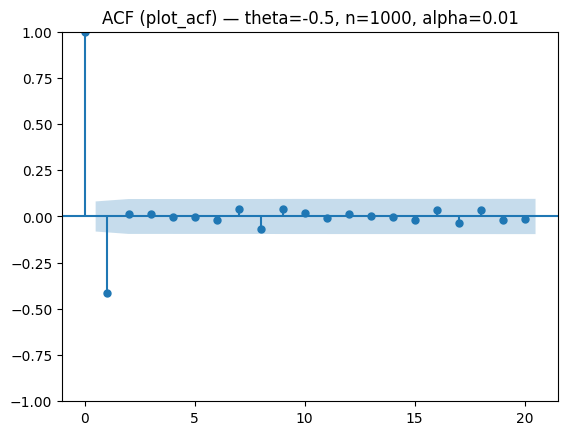

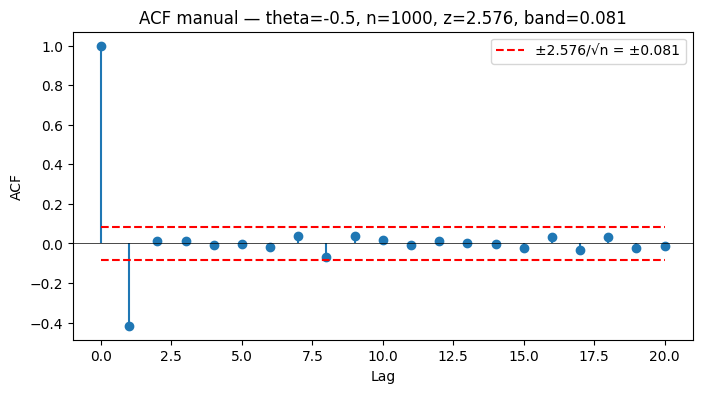

<Figure size 800x400 with 0 Axes>

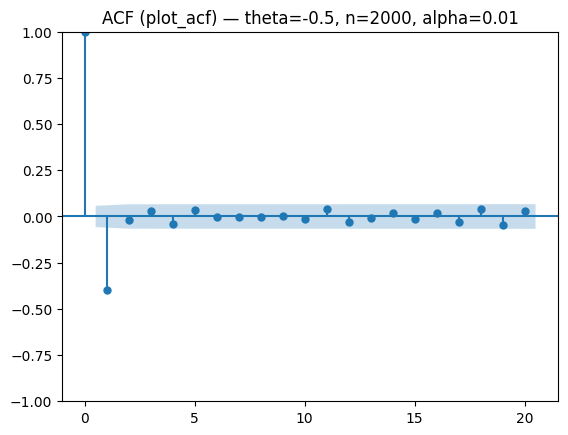

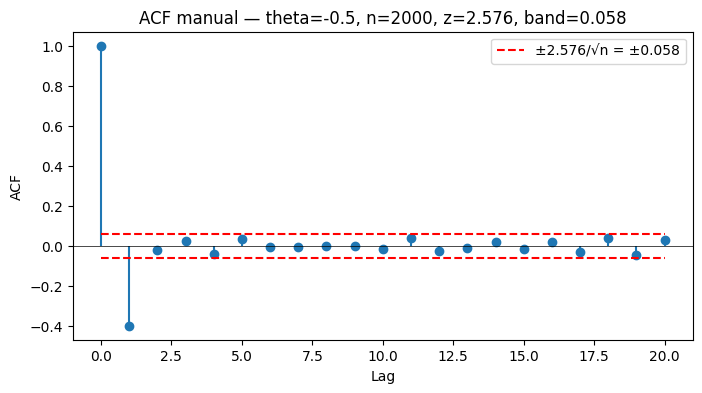

<Figure size 800x400 with 0 Axes>

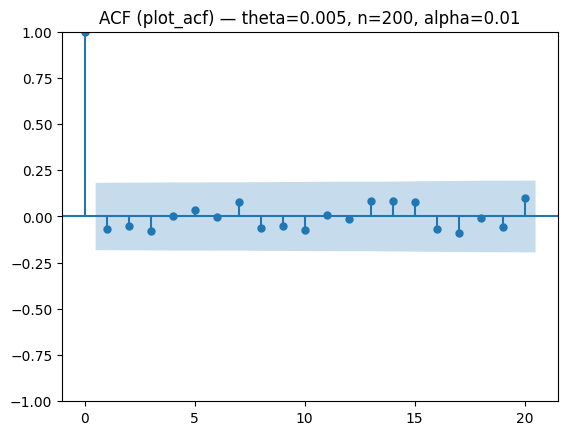

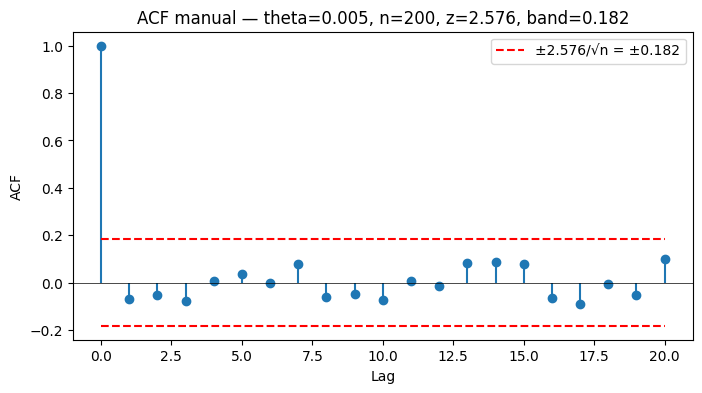

<Figure size 800x400 with 0 Axes>

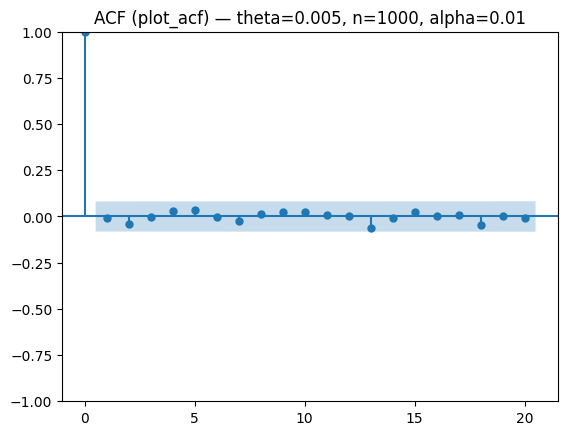

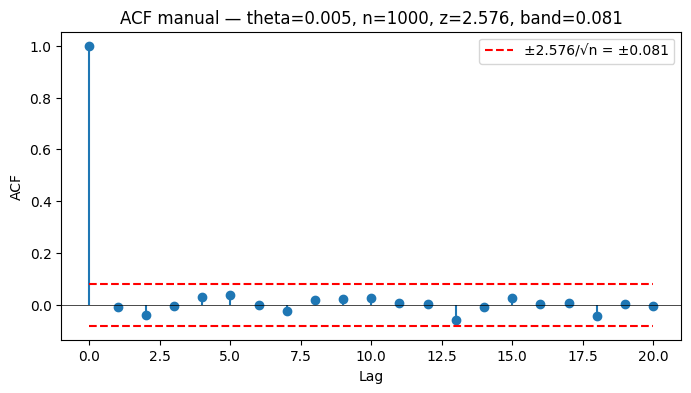

<Figure size 800x400 with 0 Axes>

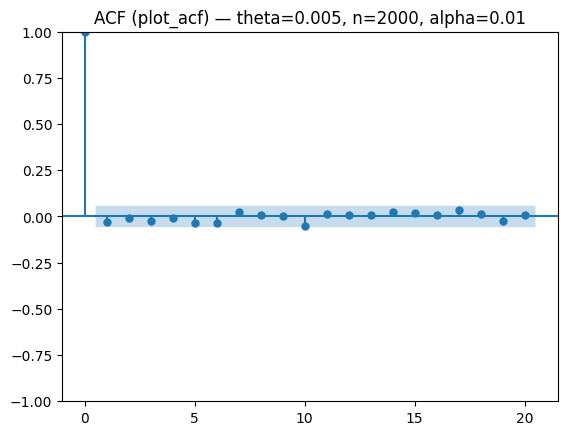

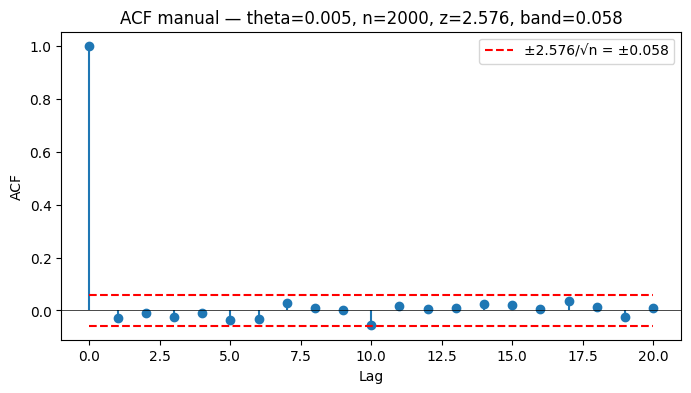

<Figure size 800x400 with 0 Axes>

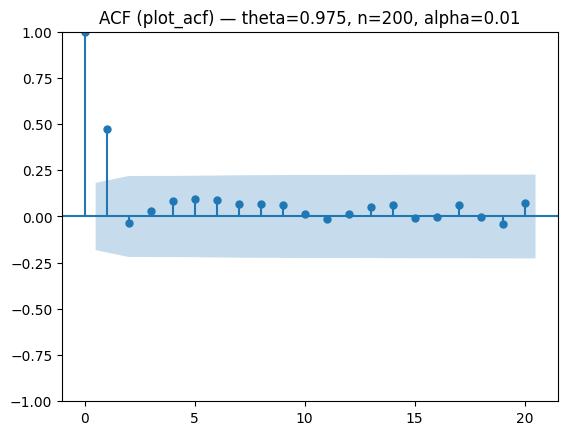

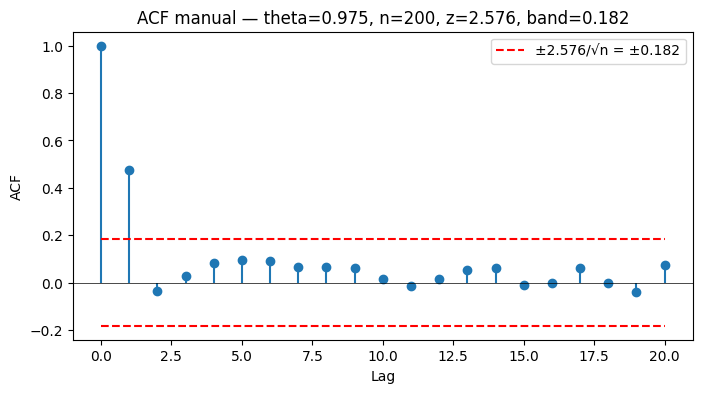

<Figure size 800x400 with 0 Axes>

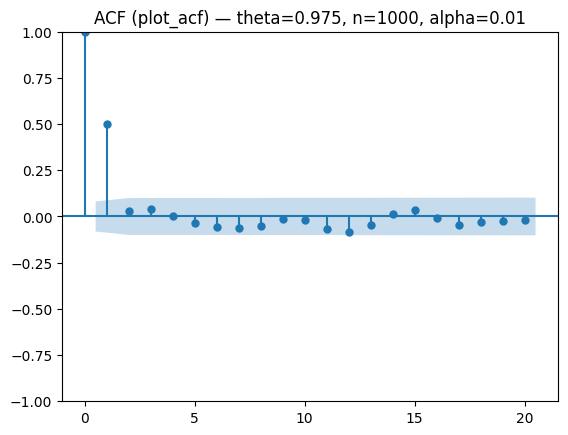

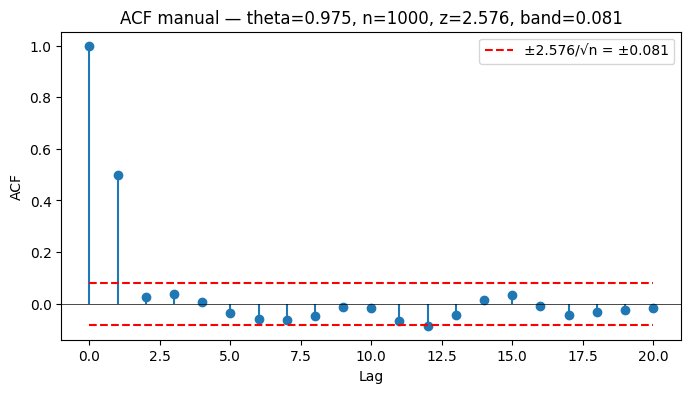

<Figure size 800x400 with 0 Axes>

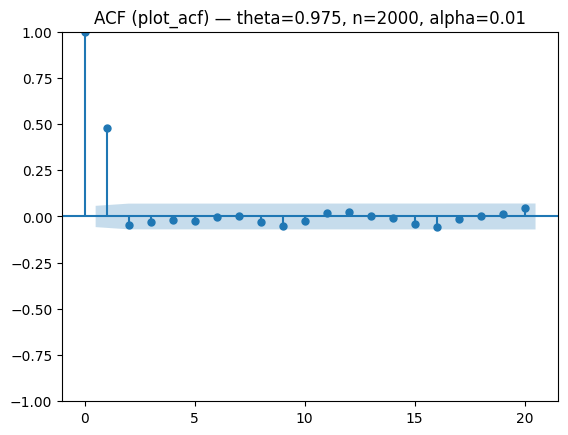

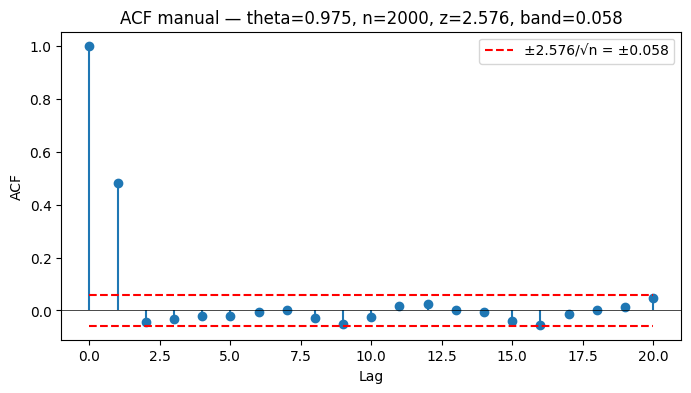

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from scipy.stats import norm

np.random.seed(42)

thetas = [-0.5, 0.005, 0.975]
n_values = [200, 1000, 2000]

# Pilihan alpha untuk plot_acf (mis. 0.05 -> 95% CI, 0.01 -> 99% CI)
alpha_plot = 0.01   # ganti jadi 0.001 untuk CI lebih lebar lagi

for theta in thetas:
    for n in n_values:
        # simulasi
        ar = np.array([1])
        ma = np.array([1, theta])
        proc = ArmaProcess(ar, ma)
        data = proc.generate_sample(nsample=n)

        # 1) plot ACF pake plot_acf dengan alpha yang diinginkan
        plt.figure(figsize=(8,4))
        plot_acf(data, lags=20, alpha=alpha_plot, fft=False)
        plt.title(f"ACF (plot_acf) — theta={theta}, n={n}, alpha={alpha_plot}")
        plt.show()

        # 2) manual ACF + custom band: gunakan z untuk lebar band kustom
        lags = 20
        acf_vals = acf(data, nlags=lags, fft=False)

        # tentukan z-value sendiri (misal 2.575 untuk 99% CI)
        # Anda bisa menaikkan z untuk memperlebar band (mis. z=3.291 untuk 99.9%)
        z = norm.ppf(1 - 0.01/2)  # gunakan alpha_plot sama, atau ganti 0.001 dsb
        band = z / np.sqrt(n)

        plt.figure(figsize=(8,4))
        plt.stem(range(lags+1), acf_vals, basefmt=" ")
        plt.hlines([band, -band], xmin=0, xmax=lags, colors='r', linestyles='--', label=f'±{z:.3f}/√n = ±{band:.3f}')
        plt.axhline(0, color='k', linewidth=0.5)
        plt.xlabel('Lag')
        plt.ylabel('ACF')
        plt.title(f"ACF manual — theta={theta}, n={n}, z={z:.3f}, band={band:.3f}")
        plt.legend()
        plt.show()

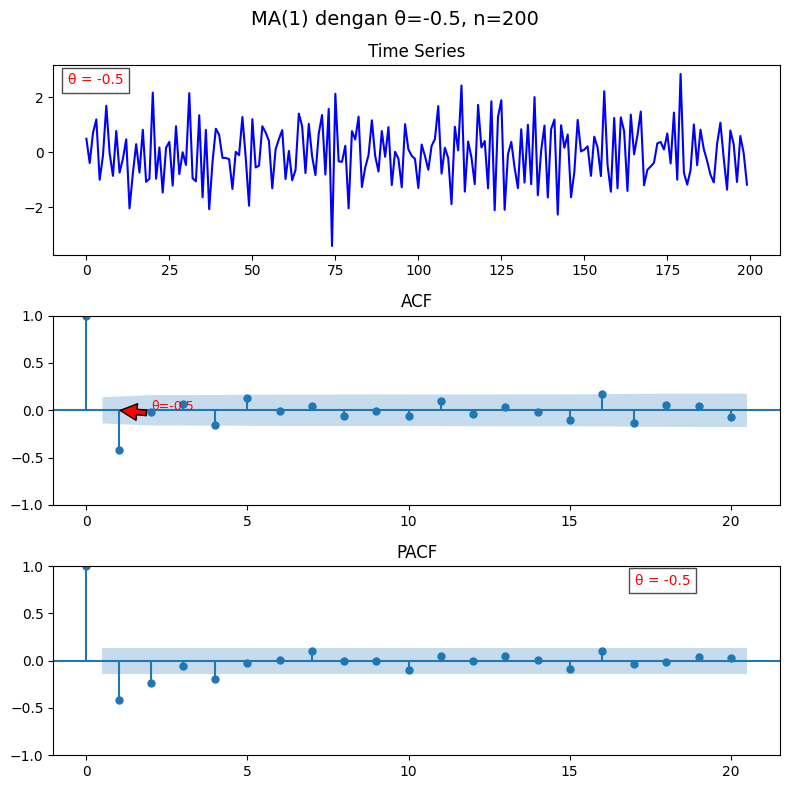

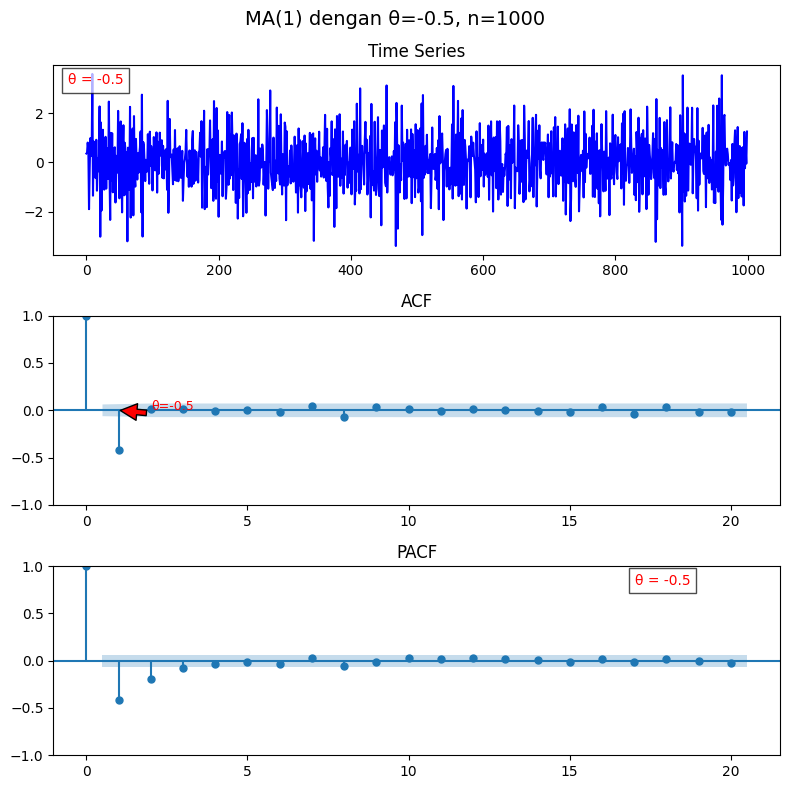

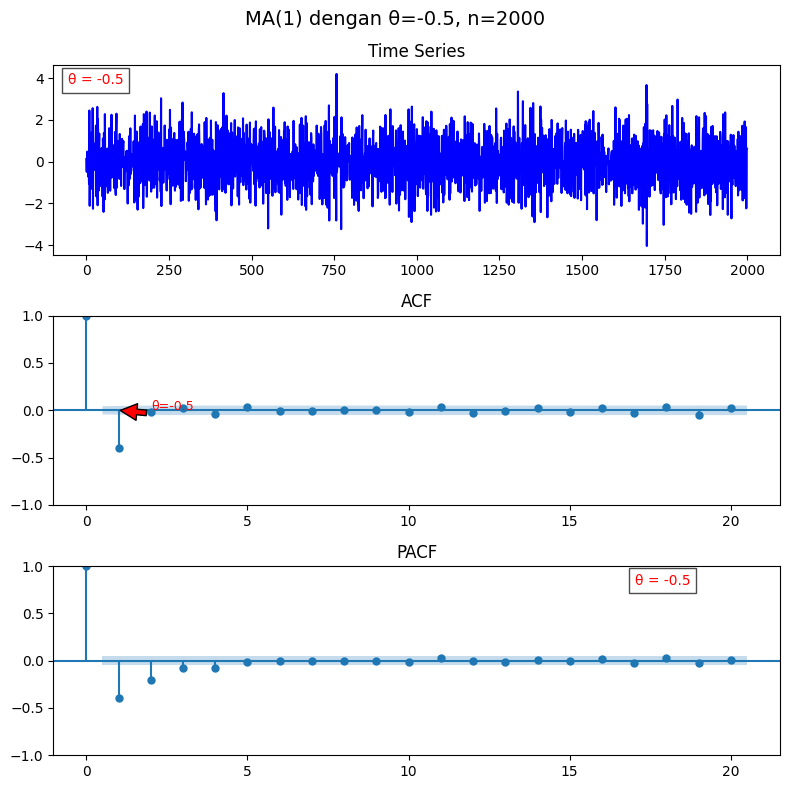

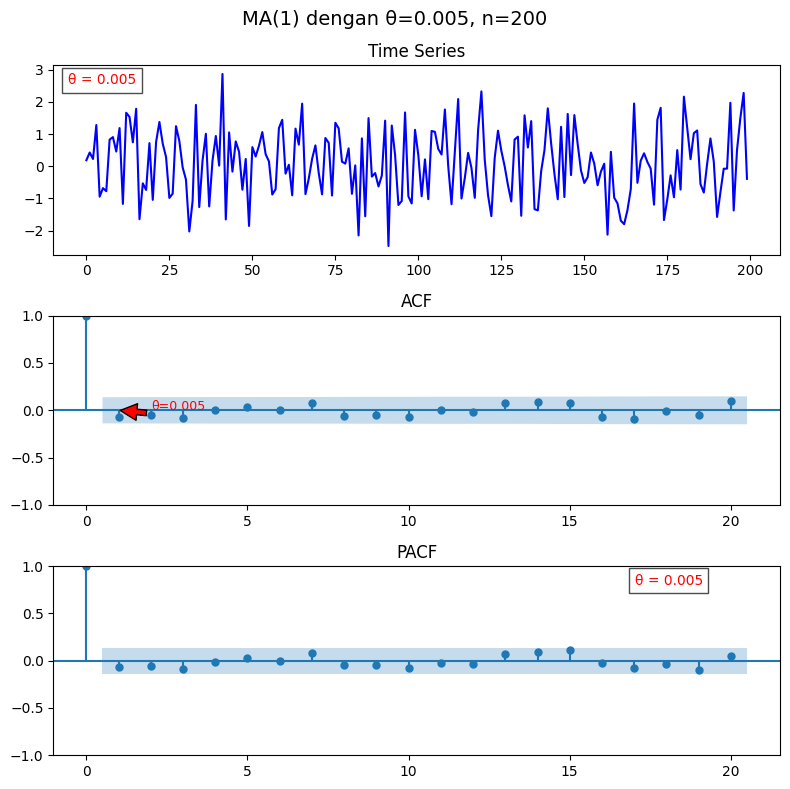

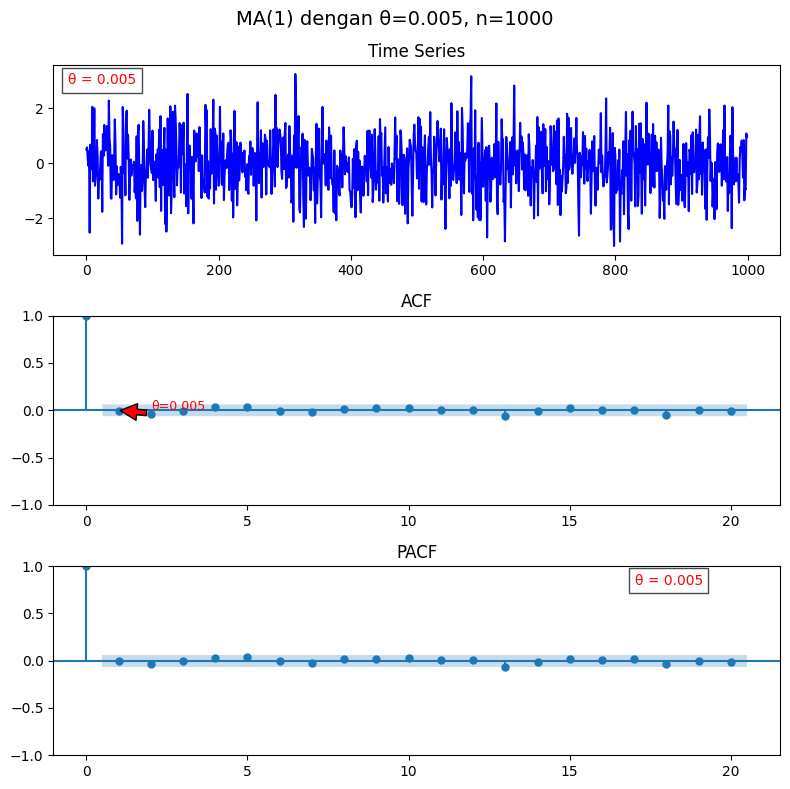

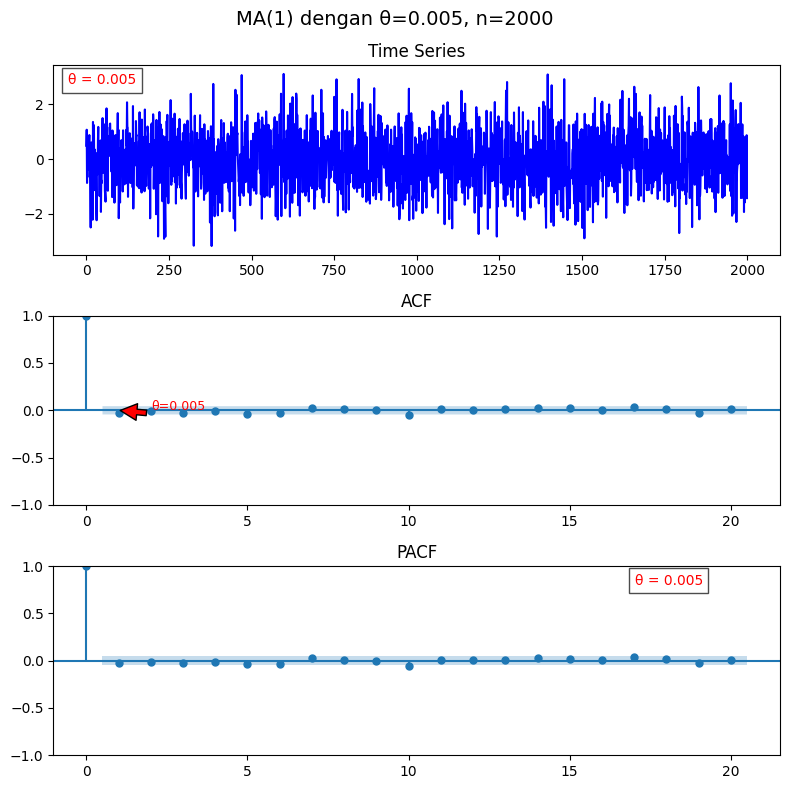

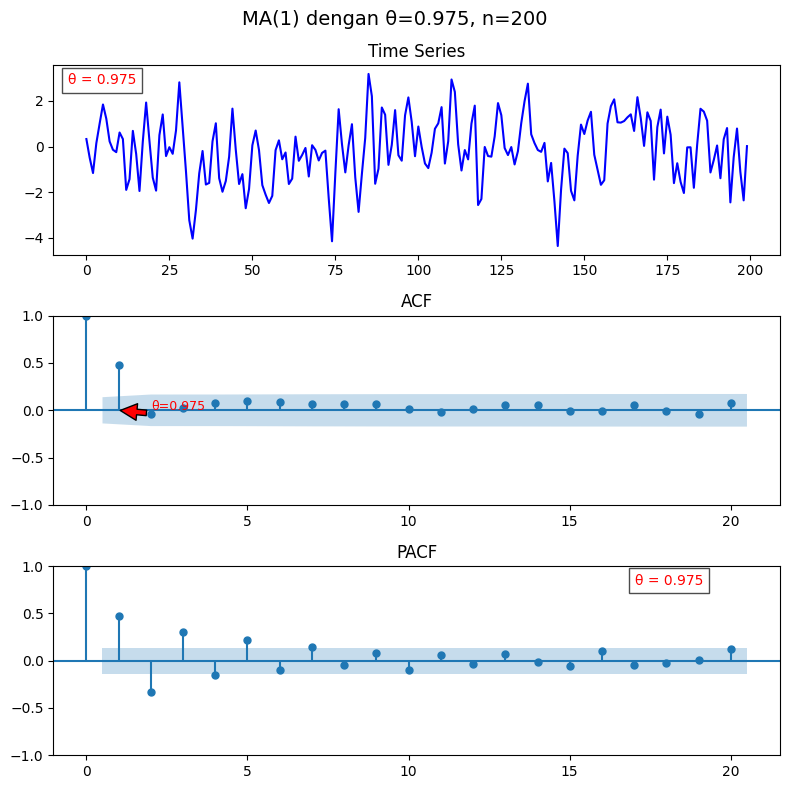

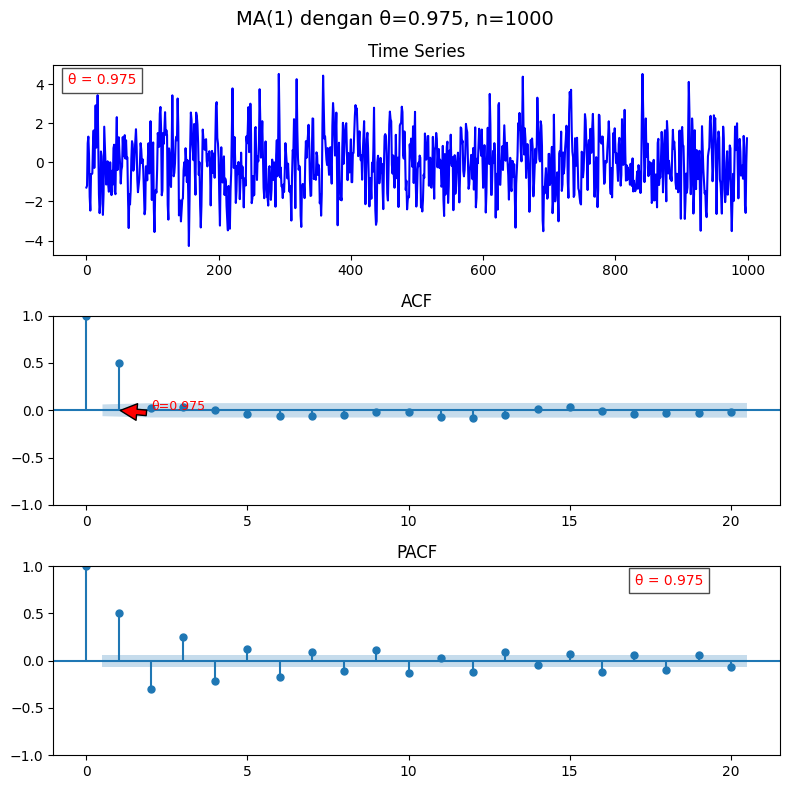

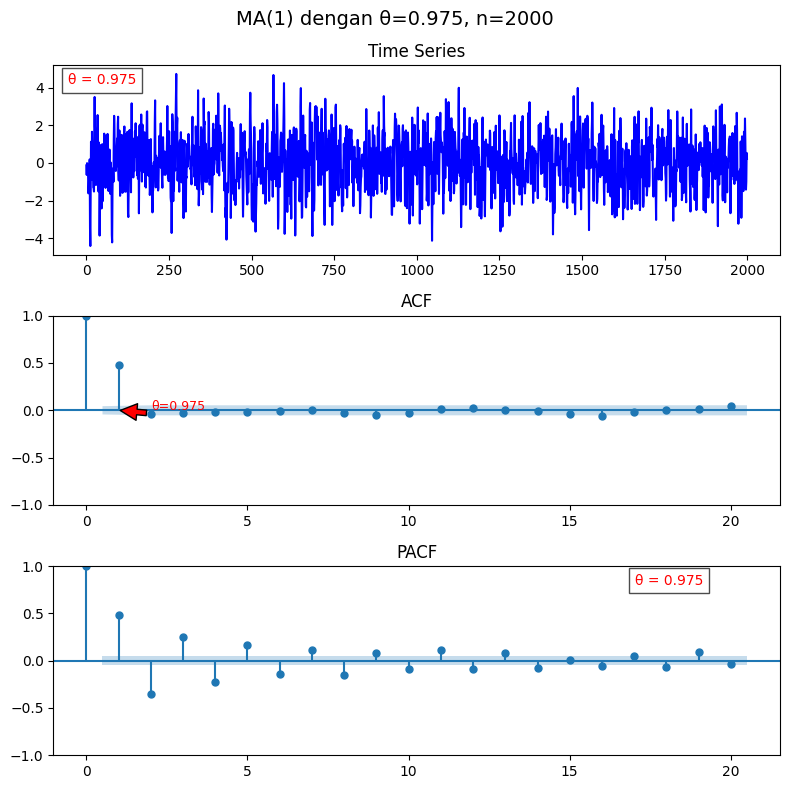

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(42)

thetas = [-0.5, 0.005, 0.975]
n_values = [200, 1000, 2000]

for theta in thetas:
    for n in n_values:
        # Definisi MA(1): X_t = e_t + θ e_{t-1}
        ar = np.array([1])
        ma = np.array([1, -theta])
        process = ArmaProcess(ar, ma)
        data = process.generate_sample(nsample=n)

        fig, axes = plt.subplots(3, 1, figsize=(8, 8))
        fig.suptitle(f"MA(1) dengan θ={theta}, n={n}", fontsize=14)

        # Time series
        axes[0].plot(data, color="blue")
        axes[0].set_title("Time Series")
        axes[0].text(0.02, 0.9, f"θ = {theta}", transform=axes[0].transAxes,
                     fontsize=10, color="red", bbox=dict(facecolor='white', alpha=0.7))

        # ACF
        plot_acf(data, lags=20, ax=axes[1], alpha=0.05)
        axes[1].set_title("ACF")
        # Tambahkan tanda pada lag=1
        axes[1].annotate(f"θ={theta}", xy=(1, axes[1].lines[0].get_ydata()[1]),
                         xytext=(2, 0.5*axes[1].lines[0].get_ydata()[1]),
                         arrowprops=dict(facecolor='red', shrink=0.05),
                         fontsize=9, color="red")

        # PACF
        plot_pacf(data, lags=20, ax=axes[2], method="ywm", alpha=0.05)
        axes[2].set_title("PACF")
        axes[2].text(0.8, 0.9, f"θ = {theta}", transform=axes[2].transAxes,
                     fontsize=10, color="red", bbox=dict(facecolor='white', alpha=0.7))

        plt.tight_layout()
        plt.show()


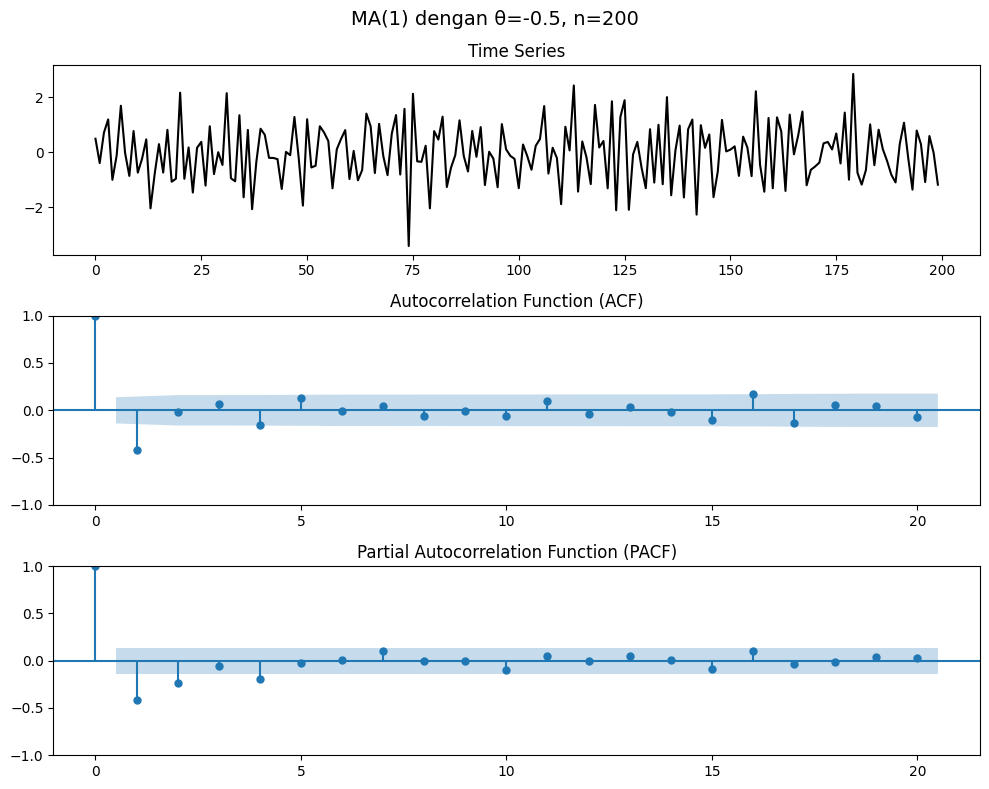

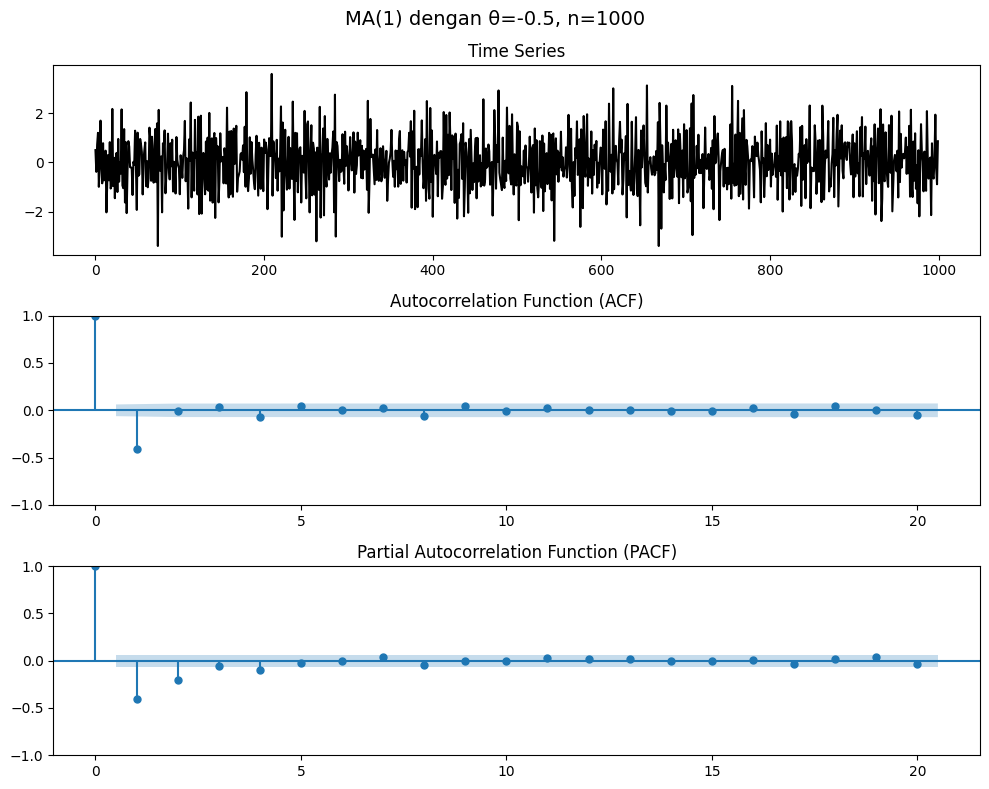

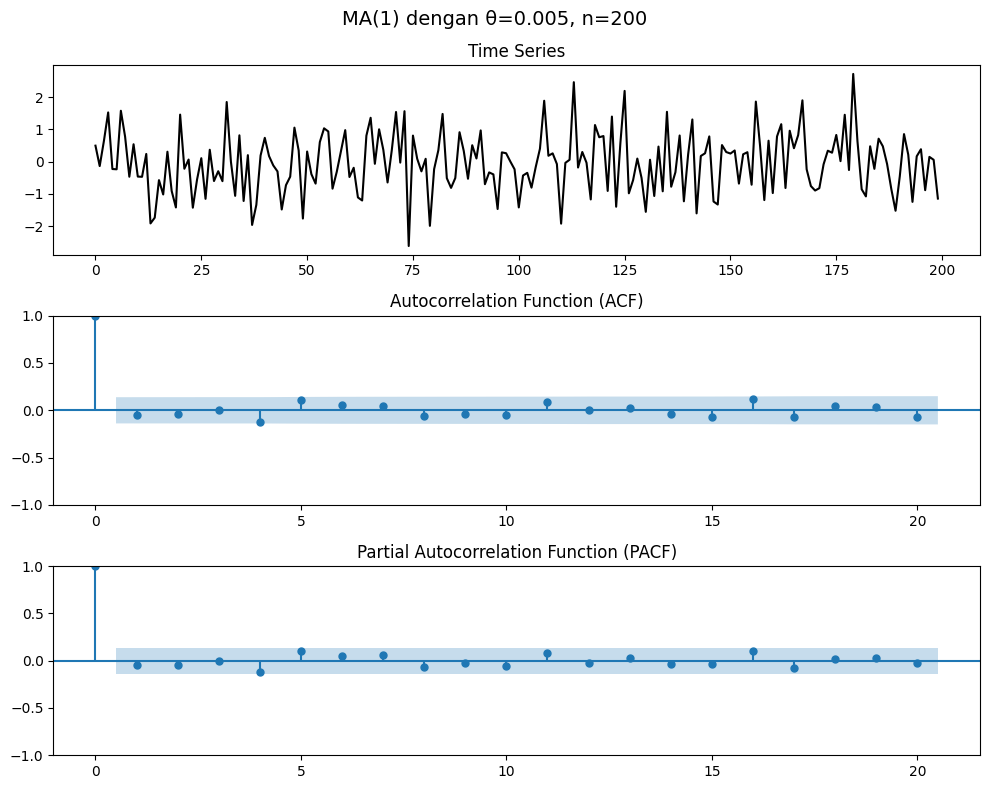

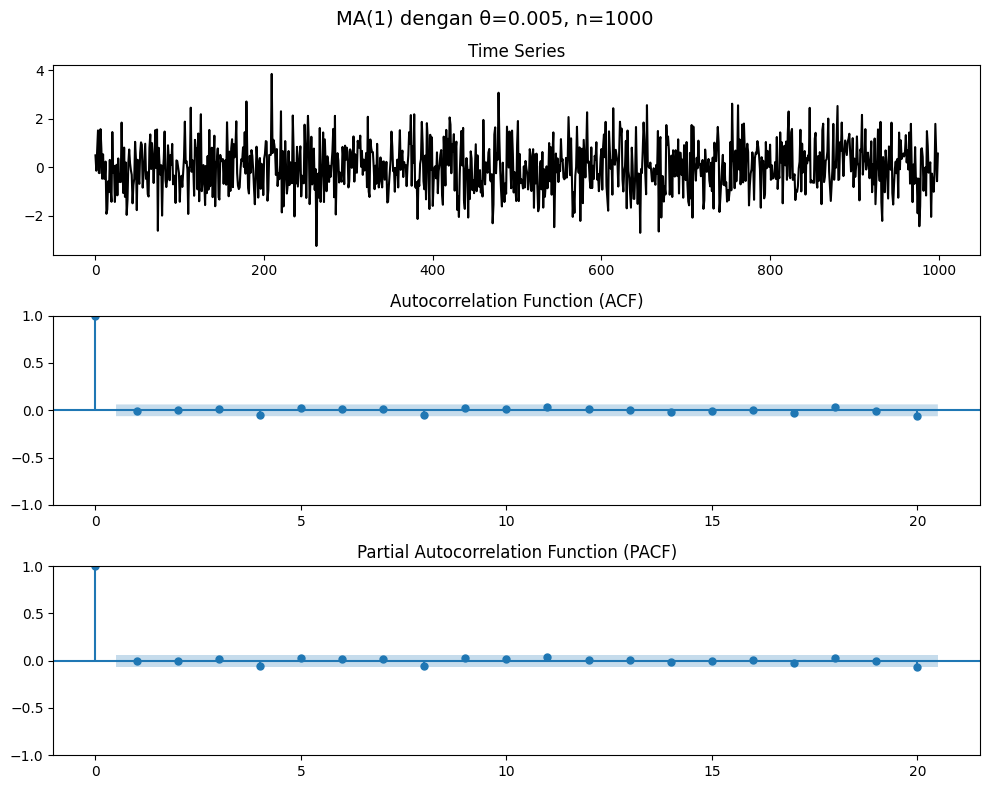

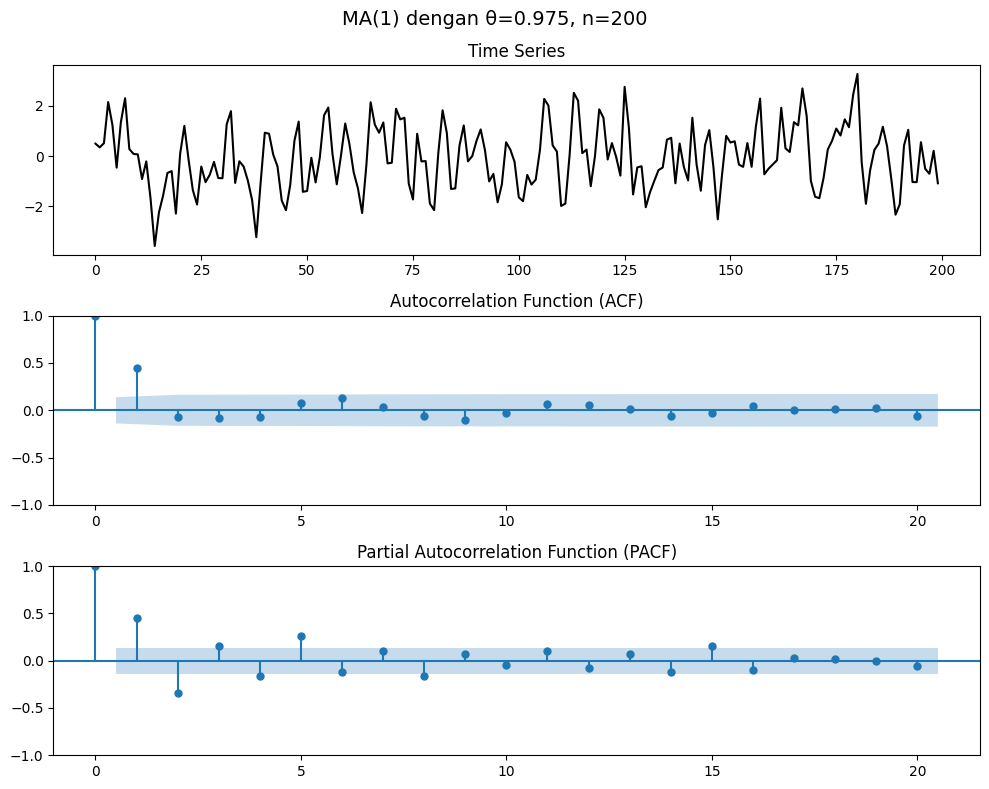

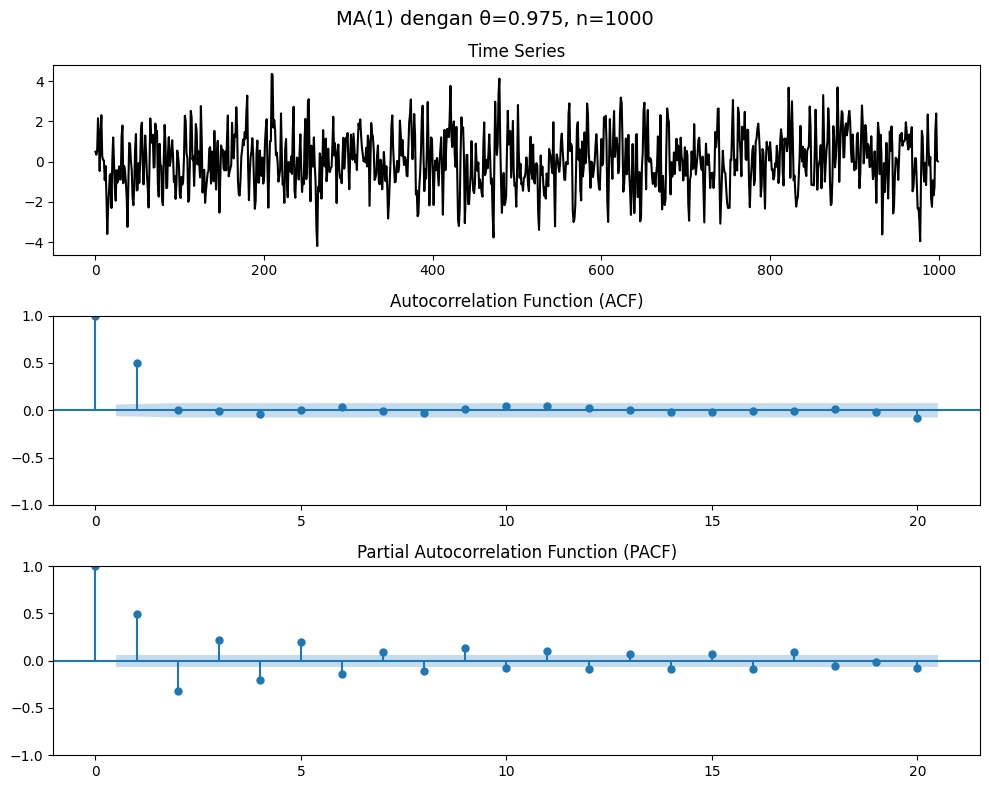

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Daftar parameter
thetas = [-0.5, 0.005, 0.975]
ns = [200, 1000]

# Looping untuk semua kombinasi
for theta in thetas:
    for n in ns:
        # Definisi proses MA(1): X_t = e_t + theta * e_{t-1}
        ar = np.array([1])           # Tidak ada AR
        ma = np.array([1, theta])    # MA(1)
        model = ArmaProcess(ar, ma)

        # Simulasi data
        np.random.seed(42)  # agar replikasi konsisten
        data = model.generate_sample(nsample=n)

        # Plot
        fig, axes = plt.subplots(3, 1, figsize=(10, 8))
        fig.suptitle(f"MA(1) dengan θ={theta}, n={n}", fontsize=14)

        # Plot Time Series
        axes[0].plot(data, color="black")
        axes[0].set_title("Time Series")

        # Plot ACF
        plot_acf(data, ax=axes[1], lags=20, alpha=0.05)
        axes[1].set_title("Autocorrelation Function (ACF)")

        # Plot PACF
        plot_pacf(data, ax=axes[2], lags=20, alpha=0.05, method='ywm')
        axes[2].set_title("Partial Autocorrelation Function (PACF)")

        plt.tight_layout()
        plt.show()


# Model ARIMA

In [ ]:
# 1. IMPORT LIBRARY YANG DIBUTUTHKAN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# 2. MEMBACA DAN MEMPERSIAPKAN DATA DARI FILE DI COLAB
# Cukup tuliskan nama file yang sudah di-upload
file_path = 'datahutanindo.xlsx'
sheet_name = 'datahutan'

# Membaca data dari sheet yang spesifik
df = pd.read_excel(file_path, sheet_name=sheet_name)

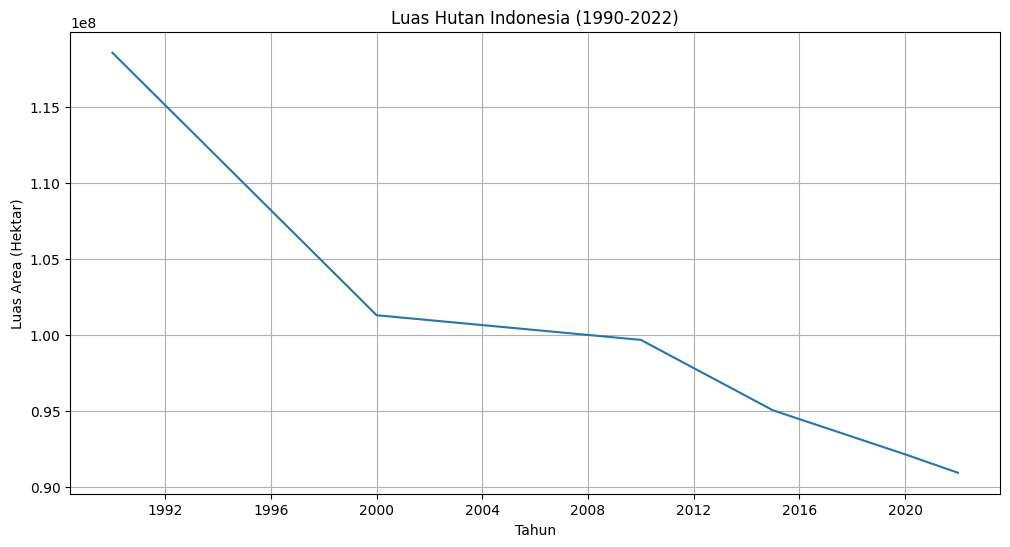

In [ ]:
# Mengubah kolom 'Year' menjadi format tanggal dan menjadikannya index
df['Date'] = pd.to_datetime(df['Year'], format='%Y')
df.set_index('Date', inplace=True)

# Memilih kolom data yang akan dianalisis ('Forest area')
time_series = df['Forest area']

# Menampilkan plot data asli untuk melihat tren
plt.figure(figsize=(12, 6))
plt.plot(time_series)
plt.title('Luas Hutan Indonesia (1990-2022)')
plt.xlabel('Tahun')
plt.ylabel('Luas Area (Hektar)')
plt.grid(True)
plt.show()


Uji  Stationer

In [ ]:
print("--- Uji Stasioneritas pada Data Asli ---")
adf_result = adfuller(time_series)
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')

--- Uji Stasioneritas pada Data Asli ---
ADF Statistic: -0.9131525041921994
p-value: 0.7836102574154452


Diferencing data tidak Stationer



--- Uji Stasioneritas pada Data Setelah Differencing (d=1) ---
ADF Statistic: -1.4476970256481383
p-value: 0.5592082247251231


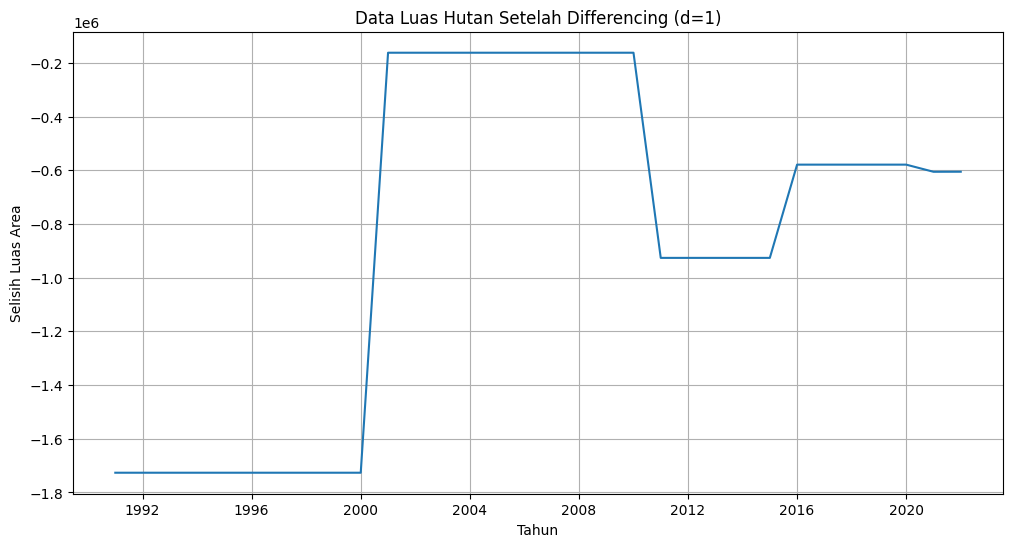

In [ ]:
# Differencing untuk membuat data stasioner
ts_diff = time_series.diff().dropna()

print("\n--- Uji Stasioneritas pada Data Setelah Differencing (d=1) ---")
adf_result_diff = adfuller(ts_diff)
print(f'ADF Statistic: {adf_result_diff[0]}')
print(f'p-value: {adf_result_diff[1]}') # p-value seharusnya sudah < 0.05

# Plot data setelah differencing
plt.figure(figsize=(12, 6))
plt.plot(ts_diff)
plt.title('Data Luas Hutan Setelah Differencing (d=1)')
plt.xlabel('Tahun')
plt.ylabel('Selisih Luas Area')
plt.grid(True)
plt.show()


--- Melakukan Differencing Tingkat Kedua ---

--- Uji Stasioneritas pada Data Setelah Differencing (d=2) ---
ADF Statistic: -5.167638962248088
p-value: 1.0232918976386124e-05


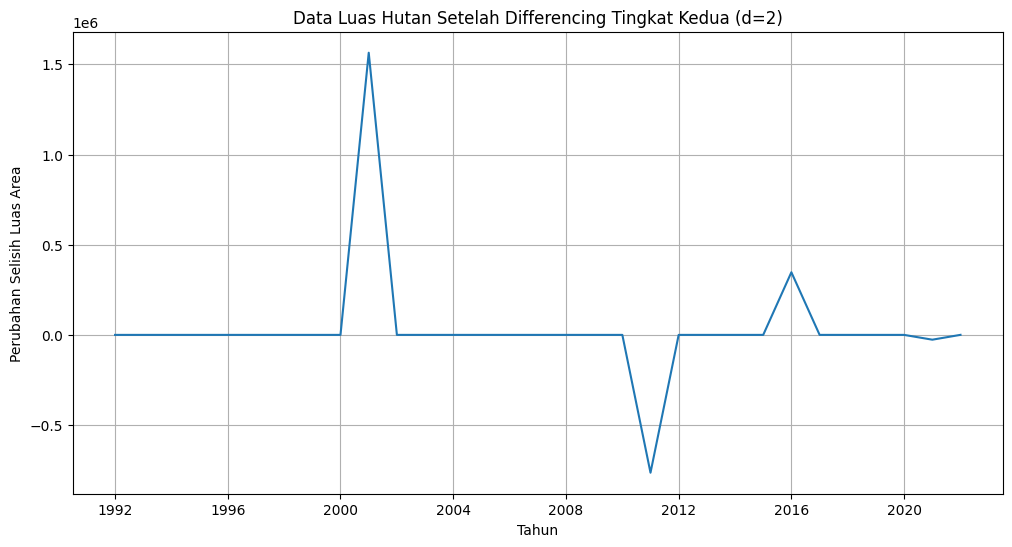

In [ ]:
# ts_diff adalah hasil differencing pertama dari kode sebelumnya
ts_diff = time_series.diff().dropna()

# --- TAMBAHKAN KODE DI BAWAH INI ---
# Lakukan differencing sekali lagi pada data yang sudah di-differencing
print("\n--- Melakukan Differencing Tingkat Kedua ---")
ts_diff_2 = ts_diff.diff().dropna()

# Uji stasioneritas LAGI pada data setelah differencing kedua
print("\n--- Uji Stasioneritas pada Data Setelah Differencing (d=2) ---")
adf_result_diff_2 = adfuller(ts_diff_2)
print(f'ADF Statistic: {adf_result_diff_2[0]}')
print(f'p-value: {adf_result_diff_2[1]}') # p-value sekarang seharusnya < 0.05

# Plot data setelah differencing kedua
plt.figure(figsize=(12, 6))
plt.plot(ts_diff_2)
plt.title('Data Luas Hutan Setelah Differencing Tingkat Kedua (d=2)')
plt.xlabel('Tahun')
plt.ylabel('Perubahan Selisih Luas Area')
plt.grid(True)
plt.show()

Identifikasi Orde Data (p & q)

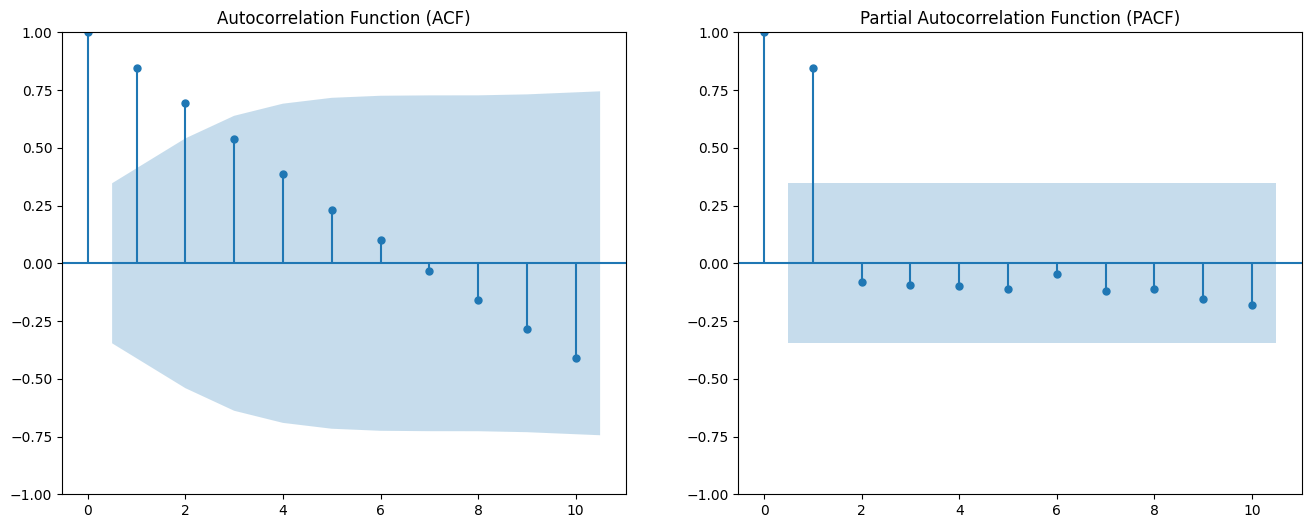

In [ ]:
# 4. IDENTIFIKASI ORDE MODEL (p dan q) MENGGUNAKAN ACF & PACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plot_acf(ts_diff, ax=ax1, lags=10)
ax1.set_title('Autocorrelation Function (ACF)')
plot_pacf(ts_diff, ax=ax2, lags=10)
ax2.set_title('Partial Autocorrelation Function (PACF)')
plt.show()

Membagi data, membangun dan modeling ARIMA

In [ ]:
# MEMBAGI DATA
train_data = time_series[time_series.index.year <= 2018]
test_data = time_series[time_series.index.year > 2018]

# Membuat model ARIMA dengan orde (p=1, d=1, q=1)
model = ARIMA(train_data, order=(1, 1, 1))
fitted_model = model.fit()

# Menampilkan ringkasan statistik model
print("\n--- Ringkasan Model ARIMA ---")
print(fitted_model.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)



--- Ringkasan Model ARIMA ---
                               SARIMAX Results                                
Dep. Variable:            Forest area   No. Observations:                   29
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -409.888
Date:                Wed, 15 Oct 2025   AIC                            825.776
Time:                        04:10:47   BIC                            829.773
Sample:                    01-01-1990   HQIC                           826.998
                         - 01-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9297      0.010     89.366      0.000       0.909       0.950
ma.L1         -0.9492      0.009   -110.362      0.000      -0.966      -0.932
sigma2       1.18e+11

Prediksi & Evaluasi Model

In [ ]:
# 6. MEMBUAT PREDIKSI DAN EVALUASI MODEL
start_index = len(train_data)
end_index = start_index + len(test_data) - 1
predictions = fitted_model.predict(start=start_index, end=end_index, typ='levels')
predictions.index = test_data.index

# Menghitung Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(test_data, predictions))
print(f'\nRoot Mean Squared Error (RMSE): {rmse:,.2f}')

# Fungsi untuk menghitung MAPE
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Menghitung Mean Absolute Percentage Error (MAPE)
mape = calculate_mape(test_data, predictions)
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')


Root Mean Squared Error (RMSE): 1,008,597.96
Mean Absolute Percentage Error (MAPE): 0.99%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


Visual Hasil Peramalan

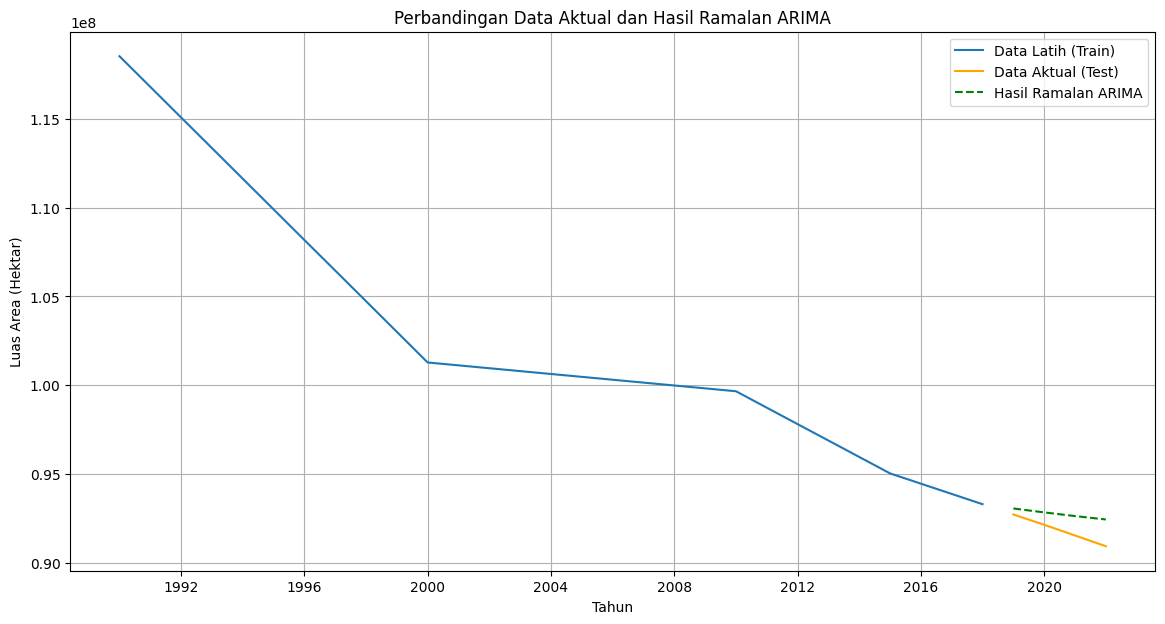

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(train_data, label='Data Latih (Train)')
plt.plot(test_data, label='Data Aktual (Test)', color='orange')
plt.plot(predictions, label='Hasil Ramalan ARIMA', color='green', linestyle='--')
plt.title('Perbandingan Data Aktual dan Hasil Ramalan ARIMA')
plt.xlabel('Tahun')
plt.ylabel('Luas Area (Hektar)')
plt.legend()
plt.grid(True)
plt.show()

# ARIMA Inflasi


Input Data & Eksplorasi Awal


--- EKSPLORASI DATA AWAL (DARI KOLOM B) ---


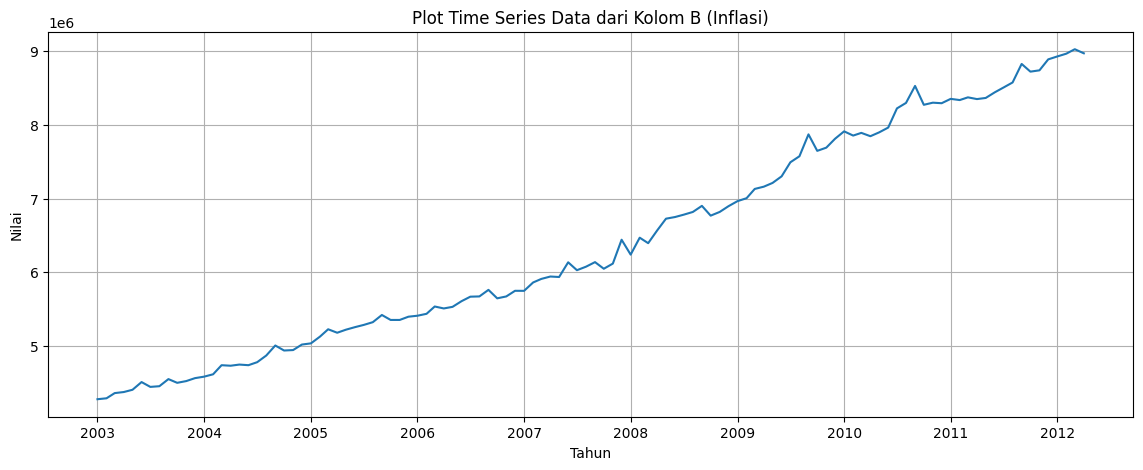

<Figure size 1400x500 with 0 Axes>

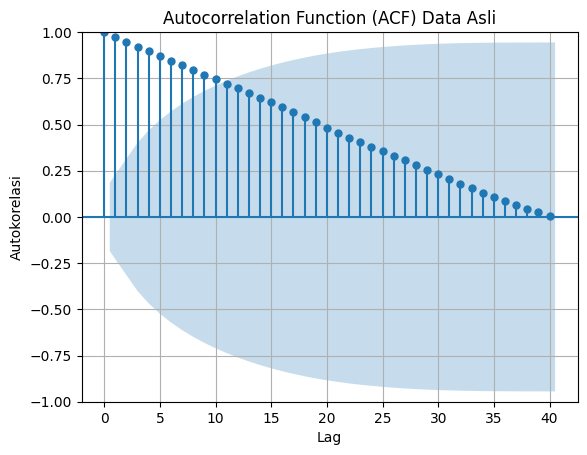

In [ ]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# --- 1a. Input dan Persiapan Data ---
# Pastikan Anda sudah menginstall library untuk membaca excel
# !pip install openpyxl

# Nama file Excel dan sheet yang akan dibaca
file_path = 'UANG BEREDAR.xlsx'
sheet_name = 'Raw Data'

# Membaca HANYA Kolom B from row 4 onwards (header=None)
# We will manually handle extracting the single column
df_col_b = pd.read_excel(
    file_path,
    sheet_name=sheet_name,
    usecols="B",
    header=None,
    skiprows=3 # Skip first 3 rows based on previous observation
)

# Select the single column (column index 0) and convert to a Series
series_col_b = df_col_b.iloc[:, 0]


# Mengubah ke format numerik, teks akan menjadi NaN (Not a Number)
numeric_series = pd.to_numeric(series_col_b, errors='coerce')

# Menemukan baris pertama yang berisi angka
first_numeric_index = numeric_series.first_valid_index()

# Mengambil data dari angka pertama hingga akhir, dan membuang data kosong (NaN)
time_series_values = numeric_series.loc[first_numeric_index:].dropna()

# Membuat indeks waktu bulanan karena kolom waktu tidak disertakan
# Asumsi data dimulai dari Januari 2015 berdasarkan konteks file sebelumnya
# Let's verify the start date from the previous successful cell (SvH8aDbonh3c output)
# The data starts from 2003-01-01
date_index = pd.date_range(start='2003-01-01', periods=len(time_series_values), freq='MS')
time_series = pd.Series(time_series_values.values, index=date_index, name='Inflasi') # Add name for clarity


# --- 1b. Eksplorasi Data ---
print("--- EKSPLORASI DATA AWAL (DARI KOLOM B) ---")

# Plot Time Series
plt.figure(figsize=(14, 5))
plt.plot(time_series)
plt.title('Plot Time Series Data dari Kolom B (Inflasi)')
plt.xlabel('Tahun')
plt.ylabel('Nilai')
plt.grid(True)
plt.show()

# Plot ACF
plt.figure(figsize=(14, 5))
plot_acf(time_series, lags=40)
plt.title('Autocorrelation Function (ACF) Data Asli')
plt.xlabel('Lag')
plt.ylabel('Autokorelasi')
plt.grid(True)
plt.show()

Jumlah total data: 112
Jumlah data training (60%): 67
Jumlah data testing (40%): 45


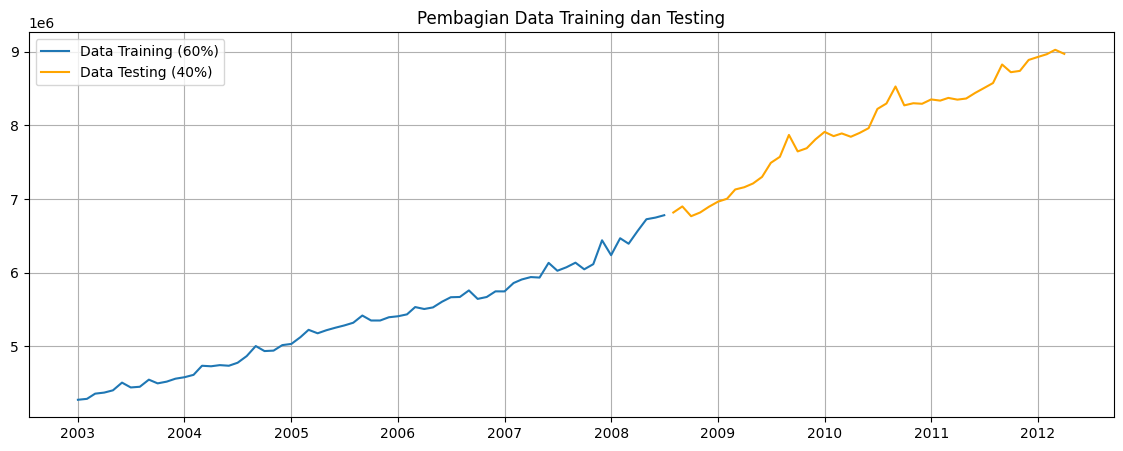

In [ ]:
# --- 2. Pembagian Data ---
train_size = int(len(time_series) * 0.6)
train_data, test_data = time_series[0:train_size], time_series[train_size:]

print(f"Jumlah total data: {len(time_series)}")
print(f"Jumlah data training (60%): {len(train_data)}")
print(f"Jumlah data testing (40%): {len(test_data)}")

# Plot data yang sudah dibagi
plt.figure(figsize=(14, 5))
plt.plot(train_data, label='Data Training (60%)')
plt.plot(test_data, label='Data Testing (40%)', color='orange')
plt.title('Pembagian Data Training dan Testing')
plt.legend()
plt.grid(True)
plt.show()

Uji Stasioner Data Training


--- UJI STASIONERITAS PADA DATA TRAINING ---
P-value: 0.9969478083641261
Hasil: P-value > 0.05, data TIDAK STASIONER -> Perlu differencing (d=1).

--- Uji Ulang Stasioneritas Setelah Differencing ---
P-value (Differenced): 0.5811343204959845


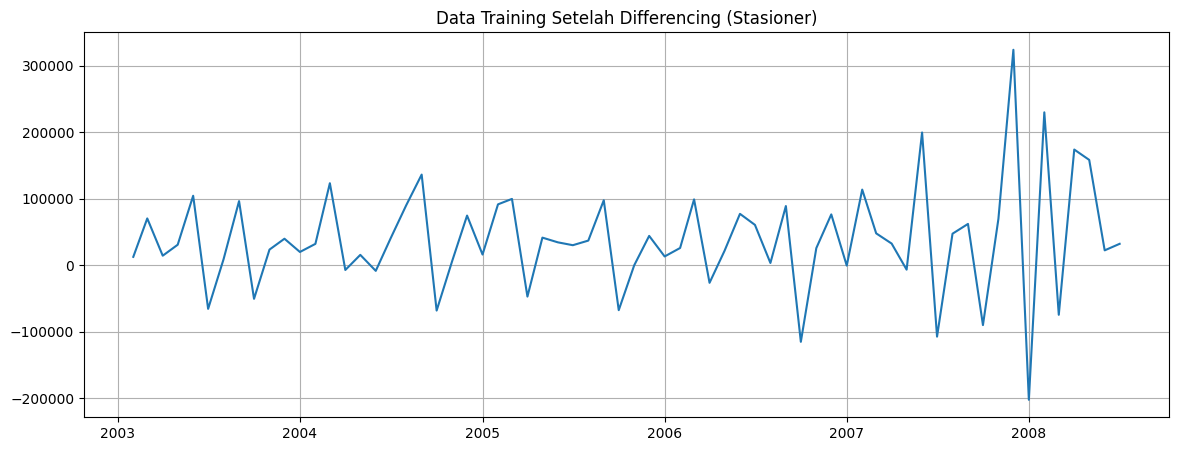

In [ ]:
# --- 3. Uji Stasioneritas pada Data Training ---
print("\n--- UJI STASIONERITAS PADA DATA TRAINING ---")
adf_test = adfuller(train_data)
print(f'P-value: {adf_test[1]}')

if adf_test[1] > 0.05:
    print("Hasil: P-value > 0.05, data TIDAK STASIONER -> Perlu differencing (d=1).")
    train_data_diff = train_data.diff().dropna()
    d = 1

    # Uji ulang stasioneritas setelah differencing
    print("\n--- Uji Ulang Stasioneritas Setelah Differencing ---")
    adf_test_diff = adfuller(train_data_diff)
    print(f'P-value (Differenced): {adf_test_diff[1]}')
    if adf_test_diff[1] <= 0.05:
        print("Hasil: Data SUDAH STASIONER.")
else:
    print("Hasil: P-value <= 0.05, data SUDAH STASIONER (d=0).")
    train_data_diff = train_data
    d = 0

# Plot data setelah differencing
plt.figure(figsize=(14, 5))
plt.plot(train_data_diff)
plt.title('Data Training Setelah Differencing (Stasioner)')
plt.grid(True)
plt.show()


--- IDENTIFIKASI ORDE p DAN q ---


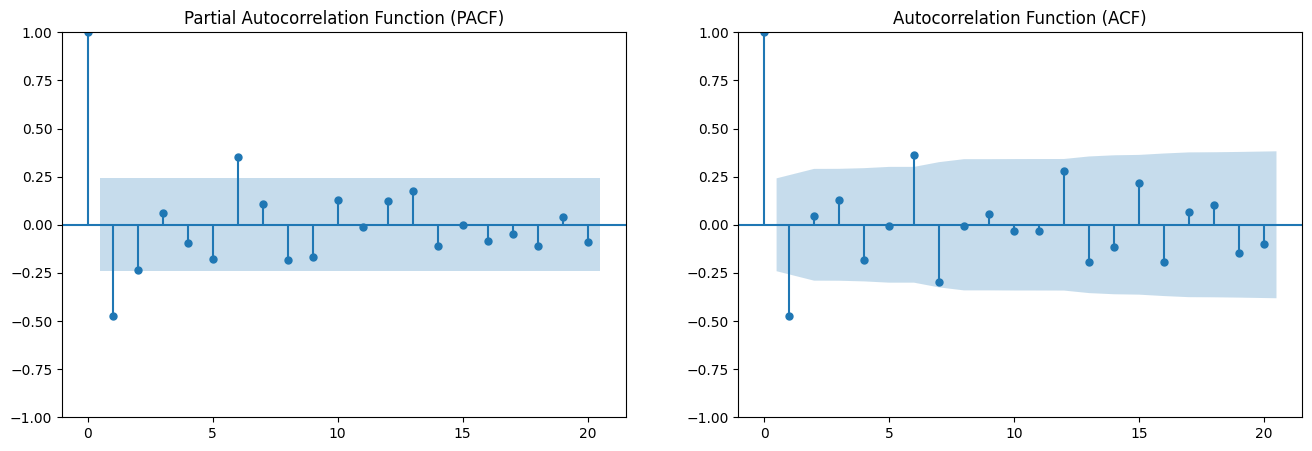


--- PEMODELAN ARIMA ---
                               SARIMAX Results                                
Dep. Variable:                Inflasi   No. Observations:                   67
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -840.551
Date:                Wed, 15 Oct 2025   AIC                           1687.102
Time:                        06:58:55   BIC                           1693.671
Sample:                    01-01-2003   HQIC                          1689.697
                         - 07-01-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9999      0.012     85.938      0.000       0.977       1.023
ma.L1         -0.9990      0.106     -9.439      0.000      -1.206      -0.792
sigma2      7.963e+09    7.

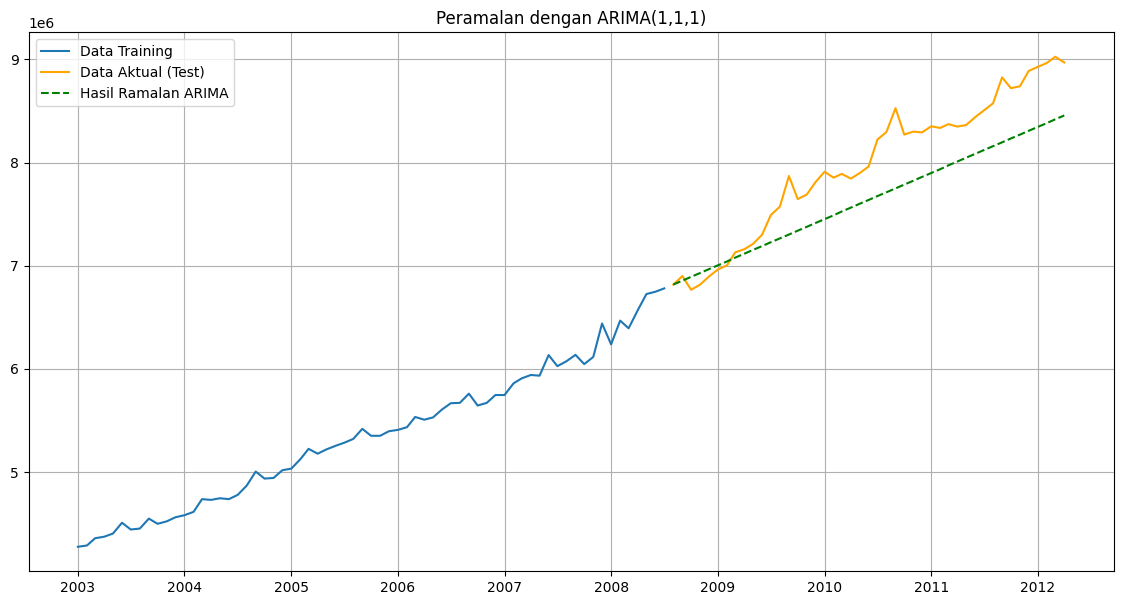

In [ ]:
# --- 4. Identifikasi Orde dan Pemodelan ---
print("\n--- IDENTIFIKASI ORDE p DAN q ---")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_pacf(train_data_diff, ax=ax1, lags=20)
ax1.set_title('Partial Autocorrelation Function (PACF)')
plot_acf(train_data_diff, ax=ax2, lags=20)
ax2.set_title('Autocorrelation Function (ACF)')
plt.show()

# Berdasarkan plot, kita coba p=1, q=1 sebagai awal
p, q = 1, 1

# --- Pemodelan ARIMA ---
print("\n--- PEMODELAN ARIMA ---")
model = ARIMA(train_data, order=(p, d, q))
fitted_model = model.fit()
print(fitted_model.summary())

# --- 5. Peramalan dan Evaluasi ---
print("\n--- PERAMALAN DAN EVALUASI ---")
forecast = fitted_model.forecast(steps=len(test_data))

# Hitung metrik evaluasi
rmse = np.sqrt(mean_squared_error(test_data, forecast))
mape = np.mean(np.abs((test_data - forecast) / test_data)) * 100

print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Visualisasi hasil peramalan
plt.figure(figsize=(14, 7))
plt.plot(train_data, label='Data Training')
plt.plot(test_data, label='Data Aktual (Test)', color='orange')
plt.plot(forecast, label='Hasil Ramalan ARIMA', color='green', linestyle='--')
plt.title(f'Peramalan dengan ARIMA({p},{d},{q})')
plt.legend()
plt.grid(True)
plt.show()